# 02 — Bronze → Silver: Auditable Cleaning Report

Rebuilds Silver **in memory** from the validated Bronze snapshot and shows, rule by rule, what changed, what was flagged, and what still needs review. It then proves the published Silver file matches this rebuild row for row.

| | |
|---|---|
| **Objective** | Explain and verify every Bronze → Silver cleaning rule with runtime evidence. |
| **Input** | `data/bronze/snapshot/` (Parquet + `metadata.json`, SHA-256 verified) |
| **Output** | Read-only audit. Canonical Silver is published only by the Airflow DAG `roombeacon_silver_build` |
| **Out of scope** | Writing Silver, modeling, or contacting MySQL |

**Contents**

- Setup
- 01. Load Bronze Snapshot
- 02. Processing Contract Matrix
- 03. General Text Standardization
- 04. Title Quality Processing
- 05. Address Standardization & Parsing
- 06. Administrative Unit Mapping
- 07. Price Validation
- 08. Area Validation
- 09. Numeric Outlier Flags
- 10. Coordinate Trust Classification
- 11. Cross-field Consistency (Price × Area)
- 12. Duplicate / Repost Candidate Hardening
- 13. Temporal Semantics Validation
- 14. Final Row Quality Status
- 15. Silver Dataset Contract & Lineage
- 16. Pre-Silver Quality Gate
- 17. Compare with Published Canonical Silver
- 18. Final Silver Validation & Health
- Summary

## Where this notebook sits

```mermaid
flowchart LR
    BR[("Bronze snapshot<br/>Parquet")] --> NB01 & NB02
    NB02 --> SV[("Silver<br/>rental_listings.parquet")]
    SV --> NB03 --> NB04 --> CH[("Locked champion<br/>LightGBM F4 RAW")]
    SV --> NB05
    CH --> NB06 & NB07
    NB01["01 · Raw EDA"]
    NB02["02 · Bronze → Silver"]
    NB03["03 · Feature contract"]
    NB04["04 · Price model"]
    NB05["05 · Nearby search"]
    NB06["06 · Shadow validation"]
    NB07["07 · Performance"]
    classDef current fill:#2a78d6,color:#ffffff,stroke:#184f95
    class NB02 current
```

The highlighted step is this notebook.

## How Bronze becomes Silver

```mermaid
flowchart TD
    B[("Bronze snapshot<br/>one row per rental_post_id")] --> T["Text standardization<br/>*_clean fields"]
    T --> A["Address parsing<br/>street / ward / district / province"]
    A --> W["Ward mapping<br/>internal reference, never forced"]
    W --> N["Price & area validation<br/>lineage-aligned values only"]
    N --> F["Flags: outliers · coordinates · price×area<br/>duplicates · temporal"]
    F --> R["Row quality roll-up<br/>READY / READY_WITH_FLAGS / REQUIRES_REVIEW"]
    R --> G{"Pre-Silver<br/>quality gate"}
    G -->|PASS| S[("Silver Parquet<br/>published by Airflow")]
    G -->|FAIL| X["Stop: nothing is published"]
```

Rules never delete rows or overwrite raw fields: every decision is stored as a status column next to
the original value. The canonical transformation is `build_silver_dataset()`; this notebook only
explains it.

## Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    p
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "crawler").is_dir() and (p / "analytics").is_dir()
)
sys.path.insert(0, str(PROJECT_ROOT))

import json

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from IPython.display import Markdown, display

load_dotenv(PROJECT_ROOT / ".env", override=False)

from analytics.bronze.snapshot import load_bronze_snapshot
from analytics.duckdb.connection import resolve_runtime_path
from roombeacon_crawler.config.get_env import env
from notebooks.utils.notebook_style import (
    CATEGORICAL,
    STATUS,
    apply_style,
    bar_chart,
    funnel_chart,
    histogram,
    scatter_legend,
    status_chart,
)
from notebooks.utils.silver_processing import build_silver_dataset, evaluate_pre_silver_quality_gate
from notebooks.utils.silver_reporting import (
    STATUS_TIERS,
    changed_text_examples,
    duplicate_group_summary,
    flag_reason_breakdown,
    iqr_threshold_diagnostics,
    multi_flag_distribution,
    numeric_audit_report,
    sample_status_rows,
    status_summary,
    text_change_summary,
)

apply_style()
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 90)


def show_status(series, title):
    """Status table plus a tier-colored bar chart (green = healthy, amber = flag, red = review)."""
    table = status_summary(series, "Status")
    status_chart(table.set_index("Status")["Rows"], tiers=STATUS_TIERS, title=title)
    plt.show()
    display(table)
    return table

## 01. Load Bronze Snapshot

> **Why:** Freeze one SHA-256-verified Bronze snapshot so every number below refers to the same data.

**Rule:** one non-null, unique `rental_post_id` per row. Raw fields stay immutable (a deep copy is kept to prove it at the end).

In [2]:
SNAPSHOT_DIR = PROJECT_ROOT / "data" / "bronze" / "snapshot"
bronze_df, raw_evidence, RUN_CONTEXT = load_bronze_snapshot(SNAPSHOT_DIR)
conn = duckdb.connect(":memory:")

BRONZE_COLUMNS = bronze_df.columns.tolist()
RAW_FINGERPRINT = bronze_df.copy(deep=True)
assert len(bronze_df) > 0
assert bronze_df.rental_post_id.notna().all() and bronze_df.rental_post_id.is_unique

display(
    pd.Series(
        {
            "snapshot_id": RUN_CONTEXT["snapshot_id"],
            "created_at_utc": RUN_CONTEXT["snapshot_created_at_utc"],
            "rows": f"{len(bronze_df):,}",
            "observed_at range": f"{RUN_CONTEXT['min_latest_observed_at']} → {RUN_CONTEXT['max_latest_observed_at']}",
            "sources": bronze_df.source_code.nunique(),
        },
        name="value",
    ).to_frame()
)

,value
snapshot_id,db804eae-1774-4659-aa9a-255830997f5d
created_at_utc,2026-10-07T10:03:08.735593+00:00
rows,"132,494"
observed_at range,2026-09-20 12:48:44 → 2026-10-03 09:57:20
sources,9


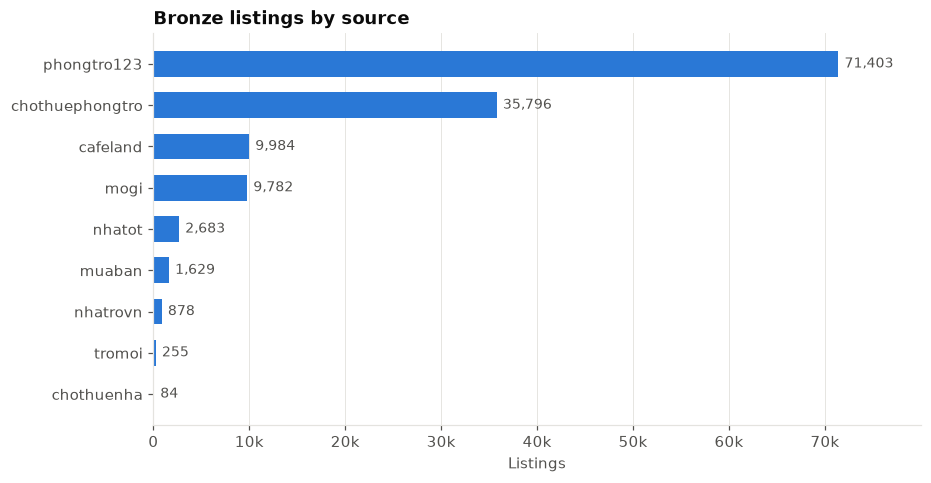

In [3]:
bar_chart(
    bronze_df.source_code.value_counts(), title="Bronze listings by source", xlabel="Listings"
)
plt.show()

## 02. Processing Contract Matrix

> **Why:** Make every transformation boundary and the raw-field preservation promise explicit.

In [4]:
processing_contract = pd.DataFrame(
    [
        [
            "Text Standardization",
            "title_raw; full_address_text; location_raw; best_address_text",
            "*_clean",
            "—",
        ],
        ["Title Quality", "title_clean", "title_quality_status", "title_quality_status"],
        [
            "Address Parsing",
            "best_address_text_clean",
            "street/ward/district/province_text_extracted",
            "parse_status",
        ],
        [
            "Ward Mapping",
            "ward_text_extracted; district_text_extracted",
            "ward_normalized; ward_current; candidates",
            "ward_mapping_status",
        ],
        [
            "Price Validation",
            "price_amount + aligned price_raw evidence",
            "price_amount_clean; lineage/regression",
            "price_quality_status",
        ],
        [
            "Area Validation",
            "area_value + aligned area_raw evidence",
            "area_value_clean; lineage/regression",
            "area_quality_status",
        ],
        [
            "Coordinate Quality",
            "map_latitude; map_longitude; map_provider; full_address_text",
            "trust evidence; has_trusted_coordinate",
            "coordinate_quality_status",
        ],
        [
            "Duplicate Audit",
            "title/address clean + price/area clean",
            "duplicate_candidate_group",
            "duplicate_candidate_status",
        ],
        ["Temporal Quality", "first/last/latest_observed_at", "—", "temporal_quality_status"],
    ],
    columns=["Processing step", "Raw / input fields", "Output fields", "Status field"],
)
processing_contract["Raw mutated?"] = "No"
display(processing_contract)

,Processing step,Raw / input fields,Output fields,Status field,Raw mutated?
0,Text Standardization,title_raw; full_address_text; location_raw; best_address_text,*_clean,—,No
1,Title Quality,title_clean,title_quality_status,title_quality_status,No
2,Address Parsing,best_address_text_clean,street/ward/district/province_text_extracted,parse_status,No
3,Ward Mapping,ward_text_extracted; district_text_extracted,ward_normalized; ward_current; candidates,ward_mapping_status,No
4,Price Validation,price_amount + aligned price_raw evidence,price_amount_clean; lineage/regression,price_quality_status,No
5,Area Validation,area_value + aligned area_raw evidence,area_value_clean; lineage/regression,area_quality_status,No
6,Coordinate Quality,map_latitude; map_longitude; map_provider; full_address_text,trust evidence; has_trusted_coordinate,coordinate_quality_status,No
7,Duplicate Audit,title/address clean + price/area clean,duplicate_candidate_group,duplicate_candidate_status,No
8,Temporal Quality,first/last/latest_observed_at,—,temporal_quality_status,No


## 03. General Text Standardization

> **Why:** Produce comparable text while keeping every raw string.

**Rule:** Unicode NFC, remove invisible/control and decorative characters, normalize whitespace and safe punctuation, turn empty results into `NULL`.

**Input → output:** `title_raw`, `full_address_text`, `location_raw`, `best_address_text` → `*_clean`.

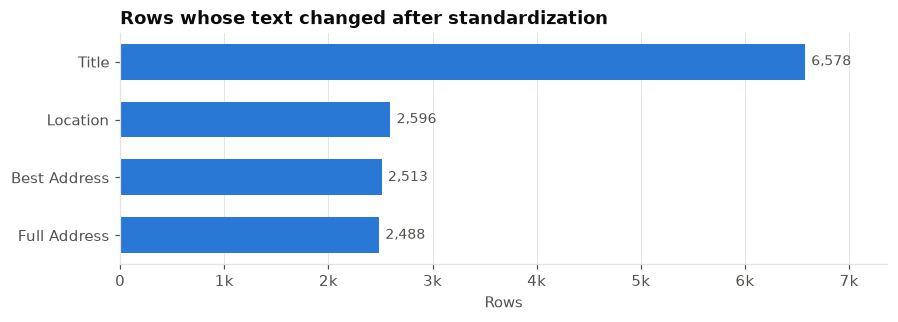

,Field,Total Rows,Raw Available,Clean Available,Changed Rows,Unchanged Rows,Changed (%),Cleaned to NULL,Recovered
0,Title,132494,131971,131971,6578,125916,4.96,0,0
1,Full Address,132494,119724,119724,2488,130006,1.88,0,0
2,Location,132494,124377,124377,2596,129898,1.96,0,0
3,Best Address,132494,124377,124377,2513,129981,1.90,0,0


In [5]:
silver_df = build_silver_dataset(bronze_df, raw_evidence)

TEXT_FIELDS = {
    "Title": ("title_raw", "title_clean"),
    "Full Address": ("full_address_text", "full_address_text_clean"),
    "Location": ("location_raw", "location_raw_clean"),
    "Best Address": ("best_address_text", "best_address_text_clean"),
}
text_summary = text_change_summary(bronze_df, silver_df, TEXT_FIELDS)
bar_chart(
    text_summary.set_index("Field")["Changed Rows"],
    title="Rows whose text changed after standardization",
)
plt.show()
display(text_summary)

Before → after examples (cleanup changes representation only; it never invents missing text):

In [6]:
display(changed_text_examples(bronze_df, silver_df, TEXT_FIELDS, 20))

,Field,Raw Text,Clean Text
0,Title,🏡Phòng Trọ Giá Rẻ 30m2 - Full Nội Thất + Ban Công - Ngay KCN Tân Bình,Phòng Trọ Giá Rẻ 30m2 - Full Nội Thất + Ban Công - Ngay KCN Tân Bình
1,Title,🏡 PHÒNG TRỌ GIÁ RẺ Mới 100% - Full Nội Thất - Ban Công - KCN Tân Bình,PHÒNG TRỌ GIÁ RẺ Mới 100% - Full Nội Thất - Ban Công - KCN Tân Bình
2,Title,🏡Phòng Trọ Mới Giá Rẻ - Full Nội Thất + Ban Công - Công Viên Phần Mềm,Phòng Trọ Mới Giá Rẻ - Full Nội Thất + Ban Công - Công Viên Phần Mềm
3,Title,🏡 Phòng Trọ Giá Rẻ - Full Nội Thất & Ban Công - Ngay Cầu Tham Lương,Phòng Trọ Giá Rẻ - Full Nội Thất & Ban Công - Ngay Cầu Tham Lương
4,Title,🏡 Phòng Mới Cao Cấp 30m2 - Full Nội Thất + Máy Giặt - Gác Cao - Tô Ký,Phòng Mới Cao Cấp 30m2 - Full Nội Thất + Máy Giặt - Gác Cao - Tô Ký
5,Full Address,"23 Nguyễn Kim, Phường Chợ Lớn, Quận 5, Hồ Chí Minh, Ngay ngã ba Bà Triệu-Nguyễn Kim - ...","23 Nguyễn Kim, Phường Chợ Lớn, Quận 5, Hồ Chí Minh, Ngay ngã ba Bà Triệu-Nguyễn Kim - ..."
6,Full Address,"25/16/1, , Tăng Nhơn Phú TP. Hồ Chí Minh","25/16/1, Tăng Nhơn Phú TP. Hồ Chí Minh"
7,Full Address,"17/6N, Đường số 22, , Hiệp Bình TP. Hồ Chí Minh","17/6N, Đường số 22, Hiệp Bình TP. Hồ Chí Minh"
8,Full Address,"Nguyễn Tri Phương, , Vườn Lài TP. Hồ Chí Minh","Nguyễn Tri Phương, Vườn Lài TP. Hồ Chí Minh"
9,Full Address,"380 Xô Viết Nghệ Tĩnh, Phường 25, Quận Bình Thạnh ⚜️NỘI THẤT TRANG BỊ ĐẦY ĐỦ⚜️ ✏ Máy đ...","380 Xô Viết Nghệ Tĩnh, Phường 25, Quận Bình Thạnh NỘI THẤT TRANG BỊ ĐẦY ĐỦ Máy điều hò..."


## 04. Title Quality Processing

> **Why:** Identify titles that are usable for downstream inspection.

**Rule:** `MISSING` when `title_clean` is null; `TOO_SHORT` when shorter than 5 characters; otherwise `USABLE`.

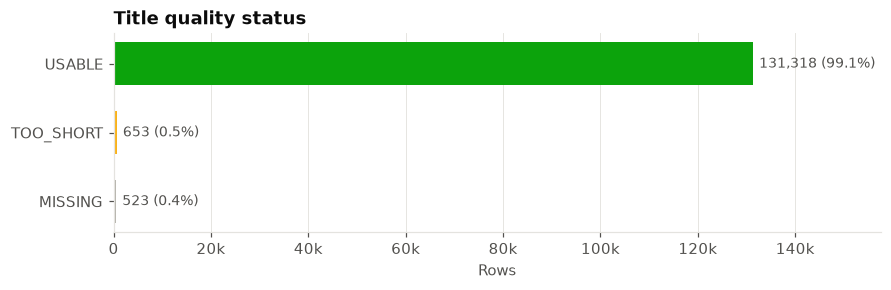

,Status,Rows,Percentage (%)
0,USABLE,131318,99.11
1,TOO_SHORT,653,0.49
2,MISSING,523,0.39


,Example Status,rental_post_id,source_code,title_raw,title_clean,title_quality_status
0,TOO_SHORT,55097,nhatrovn,01,01,TOO_SHORT
1,TOO_SHORT,55111,nhatrovn,101,101,TOO_SHORT
2,TOO_SHORT,55118,nhatrovn,102,102,TOO_SHORT
3,TOO_SHORT,55121,nhatrovn,101,101,TOO_SHORT
4,TOO_SHORT,55124,nhatrovn,103,103,TOO_SHORT
5,MISSING,54295,nhatot,NaN,None,MISSING
6,MISSING,54306,nhatot,NaN,None,MISSING
7,MISSING,54312,nhatot,NaN,None,MISSING
8,MISSING,54320,nhatot,NaN,None,MISSING
9,MISSING,54323,nhatot,NaN,None,MISSING


In [7]:
title_status = show_status(silver_df.title_quality_status, "Title quality status")
display(
    sample_status_rows(
        silver_df,
        "title_quality_status",
        ["TOO_SHORT", "MISSING"],
        ["rental_post_id", "source_code", "title_raw", "title_clean", "title_quality_status"],
        5,
    )
)

## 05. Address Standardization & Parsing

> **Why:** Standardize the best available address and expose parser evidence without guessing.

**Flow:** `best_address_text → best_address_text_clean → parser → street / ward / district / province + parse_status`. A parse status describes observed evidence; it does not certify an official address.

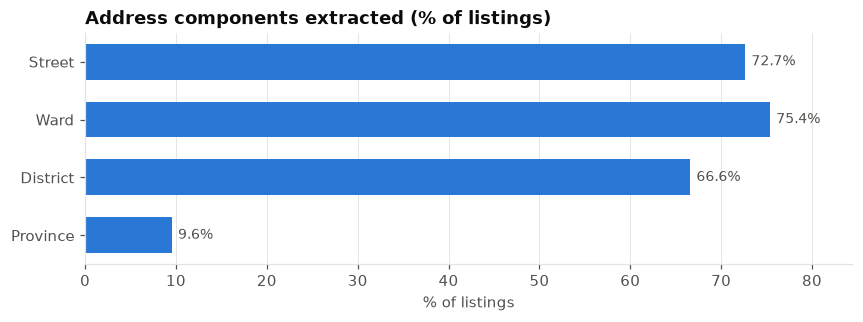

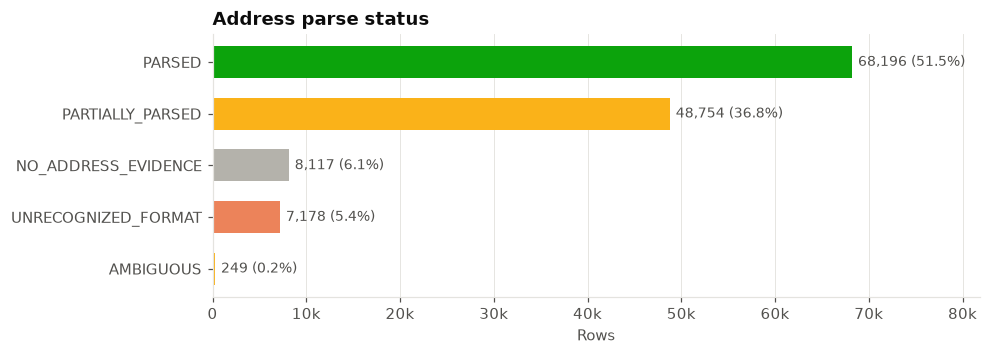

,Status,Rows,Percentage (%)
0,PARSED,68196,51.47
1,PARTIALLY_PARSED,48754,36.80
2,NO_ADDRESS_EVIDENCE,8117,6.13
3,UNRECOGNIZED_FORMAT,7178,5.42
4,AMBIGUOUS,249,0.19


In [8]:
components = {
    "Street": "street_text_extracted",
    "Ward": "ward_text_extracted",
    "District": "district_text_extracted",
    "Province": "province_text_extracted",
}
address_coverage = pd.Series(
    {label: silver_df[column].notna().mean() * 100 for label, column in components.items()}
)
bar_chart(
    address_coverage,
    title="Address components extracted (% of listings)",
    xlabel="% of listings",
    sort=False,
    fmt="{:.1f}%",
)
plt.show()
parse_status = show_status(silver_df.parse_status, "Address parse status")

In [9]:
display(
    sample_status_rows(
        silver_df,
        "parse_status",
        ["PARSED", "PARTIALLY_PARSED", "UNRECOGNIZED_FORMAT", "NO_ADDRESS_EVIDENCE"],
        [
            "best_address_text",
            "best_address_text_clean",
            "street_text_extracted",
            "ward_text_extracted",
            "district_text_extracted",
            "province_text_extracted",
            "parse_status",
        ],
        4,
    )
)

,Example Status,best_address_text,best_address_text_clean,street_text_extracted,ward_text_extracted,district_text_extracted,province_text_extracted,parse_status
0,PARSED,"Lý Chính Thắng, Phường 7 (Phường Võ Thị Sáu), Quận 3, TPHCM","Lý Chính Thắng, Phường 7 (Phường Võ Thị Sáu), Quận 3, TPHCM",NaN,Phường 7 (Phường Võ Thị Sáu),Quận 3,TPHCM,PARSED
1,PARSED,"Nguyễn Thiện Thuật, Phường 3, Quận 3, TPHCM","Nguyễn Thiện Thuật, Phường 3, Quận 3, TPHCM",NaN,Phường 3,Quận 3,TPHCM,PARSED
2,PARSED,"Bùi Hữu Nghĩa, Phường 2, Quận Bình Thạnh, TPHCM","Bùi Hữu Nghĩa, Phường 2, Quận Bình Thạnh, TPHCM",NaN,Phường 2,Quận Bình Thạnh,TPHCM,PARSED
3,PARSED,"Trường Chinh, Phường 15, Quận Tân Bình, TPHCM","Trường Chinh, Phường 15, Quận Tân Bình, TPHCM",NaN,Phường 15,Quận Tân Bình,TPHCM,PARSED
4,PARTIALLY_PARSED,"23 Nguyễn Kim, Phường Chợ Lớn, Quận 5, Hồ Chí Minh, Ngay ngã ba Bà Triệu-Nguyễn Kim - ...","23 Nguyễn Kim, Phường Chợ Lớn, Quận 5, Hồ Chí Minh, Ngay ngã ba Bà Triệu-Nguyễn Kim - ...",NaN,Phường Chợ Lớn,Quận 5,NaN,PARTIALLY_PARSED
5,PARTIALLY_PARSED,"25/16/1, , Tăng Nhơn Phú TP. Hồ Chí Minh","25/16/1, Tăng Nhơn Phú TP. Hồ Chí Minh",NaN,Phường Tăng Nhơn Phú A,Thành phố Thủ Đức,NaN,PARTIALLY_PARSED
6,PARTIALLY_PARSED,"306 Gò Dầu, P Tân Quý, Q Tân Phú - Gần Tân Quý, Tân Hương, Tân Kỳ Tân Quý - Gần chợ Tâ...","306 Gò Dầu, P Tân Quý, Q Tân Phú - Gần Tân Quý, Tân Hương, Tân Kỳ Tân Quý - Gần chợ Tâ...",NaN,NaN,Quận Tân Phú,NaN,PARTIALLY_PARSED
7,PARTIALLY_PARSED,"380 Xô Viết Nghệ Tĩnh, Phường 25, Quận Bình Thạnh ⚜️NỘI THẤT TRANG BỊ ĐẦY ĐỦ⚜️ ✏ Máy đ...","380 Xô Viết Nghệ Tĩnh, Phường 25, Quận Bình Thạnh NỘI THẤT TRANG BỊ ĐẦY ĐỦ Máy điều hò...",NaN,Phường 25,Quận Bình Thạnh,NaN,PARTIALLY_PARSED
8,UNRECOGNIZED_FORMAT,Trung Mỹ Tây TP. Hồ Chí Minh,Trung Mỹ Tây TP. Hồ Chí Minh,NaN,NaN,NaN,NaN,UNRECOGNIZED_FORMAT
9,UNRECOGNIZED_FORMAT,"Nguyễn Tri Phương, , Vườn Lài TP. Hồ Chí Minh","Nguyễn Tri Phương, Vườn Lài TP. Hồ Chí Minh",NaN,NaN,NaN,NaN,UNRECOGNIZED_FORMAT


## 06. Administrative Unit Mapping

> **Why:** Resolve extracted ward text through the internal RoomBeacon reference.

**Flow:** `ward_text_extracted → ward_normalized → reference → ward_current`. Ambiguous candidates stay unresolved; `ward_current` is never forced.

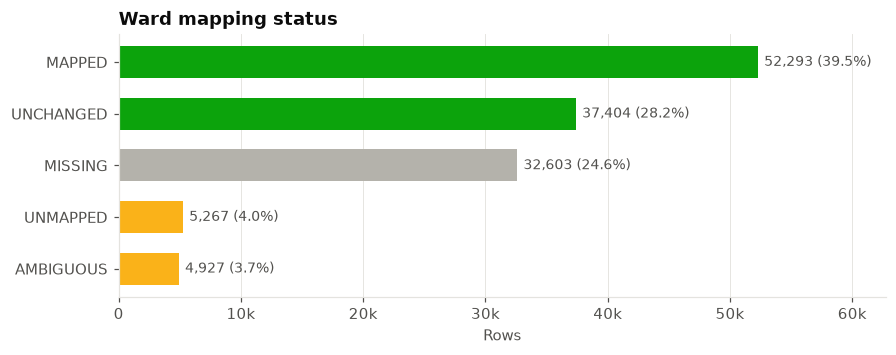

,Status,Rows,Percentage (%)
0,MAPPED,52293,39.47
1,UNCHANGED,37404,28.23
2,MISSING,32603,24.61
3,UNMAPPED,5267,3.98
4,AMBIGUOUS,4927,3.72


,Example Status,best_address_text,ward_text_extracted,district_text_extracted,ward_normalized,ward_current,ward_mapping_status
0,MAPPED,"Nguyễn Thiện Thuật, Phường 3, Quận 3, TPHCM",Phường 3,Quận 3,Phường 3,Phường Bàn Cờ,MAPPED
1,MAPPED,"Bùi Hữu Nghĩa, Phường 2, Quận Bình Thạnh, TPHCM",Phường 2,Quận Bình Thạnh,Phường 2,Phường Gia Định,MAPPED
2,MAPPED,"Phan Văn Hớn, Phường Tân Thới Nhất, Quận 12, TPHCM",Phường Tân Thới Nhất,Quận 12,Phường Tân Thới Nhất,Phường Đông Hưng Thuận,MAPPED
3,MAPPED,"Âu Cơ, Phường 10, Quận Tân Bình, TPHCM",Phường 10,Quận Tân Bình,Phường 10,Phường Bảy Hiền,MAPPED
4,MAPPED,"Lê Đức Thọ, Phường 6, Quận Gò Vấp, TPHCM",Phường 6,Quận Gò Vấp,Phường 6,Phường An Nhơn,MAPPED
5,AMBIGUOUS,"Trường Chinh, Phường 15, Quận Tân Bình, TPHCM",Phường 15,Quận Tân Bình,Phường 15,NaN,AMBIGUOUS
6,AMBIGUOUS,"Trường Chinh, Phường 15, Quận Tân Bình, TPHCM",Phường 15,Quận Tân Bình,Phường 15,NaN,AMBIGUOUS
7,AMBIGUOUS,"Thành Thái, Phường 14, Quận 10, TPHCM",Phường 14,Quận 10,Phường 14,NaN,AMBIGUOUS
8,AMBIGUOUS,"An Dương Vương, Phường 16, Quận 8, TPHCM",Phường 16,Quận 8,Phường 16,NaN,AMBIGUOUS
9,AMBIGUOUS,"Thành Thái, Phường 14, Quận 10, TPHCM",Phường 14,Quận 10,Phường 14,NaN,AMBIGUOUS


In [10]:
ward_status = show_status(silver_df.ward_mapping_status, "Ward mapping status")
display(
    sample_status_rows(
        silver_df,
        "ward_mapping_status",
        ["MAPPED", "AMBIGUOUS", "UNMAPPED"],
        [
            "best_address_text",
            "ward_text_extracted",
            "district_text_extracted",
            "ward_normalized",
            "ward_current",
            "ward_mapping_status",
        ],
        5,
    )
)

## 07. Price Validation

> **Why:** Accept only lineage-aligned prices or narrowly safe recovery; keep parser disagreement visible.

**Flow:** raw price evidence → existing numeric price → reparsed price → comparison → `price_amount_clean` + `price_quality_status` + `price_parser_comparison_status`.

A `DISAGREEMENT` never picks a winner: the existing acceptance rule still controls the clean value.

,Status,Rule,Clean value
0,VALIDATED_EXISTING,Existing value accepted; lineage and VND/month unit contract pass,Keeps existing value
1,REPARSE_ACCEPTED_CLEAN,Existing is null; aligned raw syntax reparses and passes domain/unit gates,Receives reparsed value
2,MISSING_OR_REVIEW,No accepted existing or recovery path,Remains null
3,UNKNOWN_LINEAGE,Raw evidence is not aligned to the contributing version,Remains null


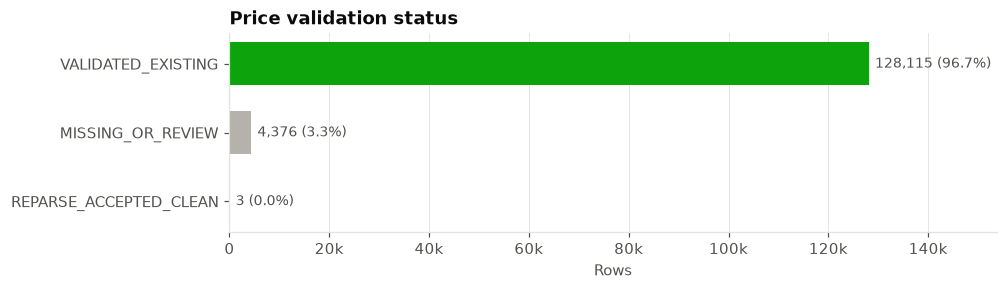

,Status,Rows,Percentage (%)
0,VALIDATED_EXISTING,128115,96.69
1,MISSING_OR_REVIEW,4376,3.30
2,REPARSE_ACCEPTED_CLEAN,3,0.00


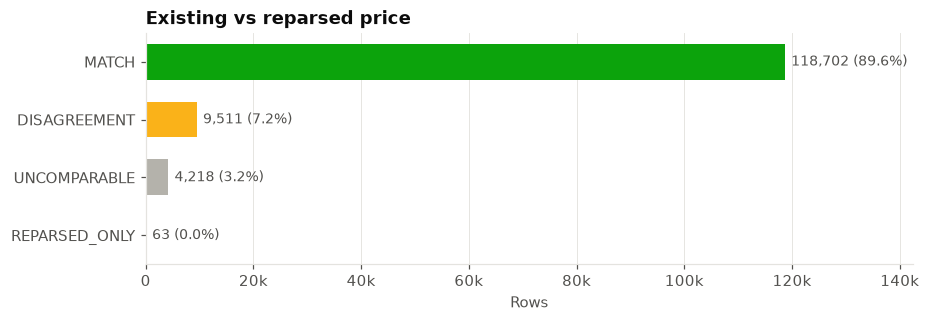

,Status,Rows,Percentage (%)
0,MATCH,118702,89.59
1,DISAGREEMENT,9511,7.18
2,UNCOMPARABLE,4218,3.18
3,REPARSED_ONLY,63,0.05


In [11]:
price_defs = pd.DataFrame(
    [
        [
            "VALIDATED_EXISTING",
            "Existing value accepted; lineage and VND/month unit contract pass",
            "Keeps existing value",
        ],
        [
            "REPARSE_ACCEPTED_CLEAN",
            "Existing is null; aligned raw syntax reparses and passes domain/unit gates",
            "Receives reparsed value",
        ],
        ["MISSING_OR_REVIEW", "No accepted existing or recovery path", "Remains null"],
        [
            "UNKNOWN_LINEAGE",
            "Raw evidence is not aligned to the contributing version",
            "Remains null",
        ],
    ],
    columns=["Status", "Rule", "Clean value"],
)
display(price_defs)
price_status = show_status(silver_df.price_quality_status, "Price validation status")
comparison_status = show_status(
    silver_df.price_parser_comparison_status, "Existing vs reparsed price"
)

In [12]:
price_audit = numeric_audit_report(bronze_df, raw_evidence, silver_df, "price")
comparison = silver_df.price_parser_comparison_status
price_metrics = pd.Series(
    {
        "Raw price available": price_audit.raw.notna().sum(),
        "Existing numeric available": price_audit.existing.notna().sum(),
        "Reparse available": price_audit.reparsed.notna().sum(),
        "Reparse accepted": price_audit.action.eq("REPARSE_ACCEPTED_CLEAN").sum(),
        "Parser agreement": comparison.eq("MATCH").sum(),
        "Parser disagreement": comparison.eq("DISAGREEMENT").sum(),
        "No price evidence": comparison.eq("NO_PRICE_EVIDENCE").sum(),
        "Negotiable (non-numeric)": price_audit.semantic.eq("NEGOTIABLE_NON_NUMERIC").sum(),
        "Reparse failed": price_audit.regression.eq("REPARSE_NULL").sum(),
        "Requires review / unavailable": silver_df.price_quality_status.isin(
            ["MISSING_OR_REVIEW", "UNKNOWN_LINEAGE"]
        ).sum(),
    },
    name="Rows",
).to_frame()
price_metrics["% of rows"] = (price_metrics.Rows / len(price_audit) * 100).round(2)
display(price_metrics)

price_examples = price_audit.assign(
    source_code=bronze_df.source_code,
    rental_post_id=bronze_df.rental_post_id,
    price_amount_clean=silver_df.price_amount_clean,
    price_parser_comparison_status=comparison,
)
display(Markdown("**Disagreement examples** — the clean value keeps the existing accepted price:"))
display(
    price_examples.loc[
        comparison.eq("DISAGREEMENT"),
        ["source_code", "rental_post_id", "raw", "existing", "reparsed", "price_amount_clean"],
    ].head(15)
)

,Rows,% of rows
Raw price available,132494,100.00
Existing numeric available,128213,96.77
Reparse available,128276,96.82
Reparse accepted,3,0.00
Parser agreement,118702,89.59
Parser disagreement,9511,7.18
No price evidence,0,0.00
Negotiable (non-numeric),182,0.14
Reparse failed,0,0.00
Requires review / unavailable,4376,3.30


**Disagreement examples** — the clean value keeps the existing accepted price:

,source_code,rental_post_id,raw,existing,reparsed,price_amount_clean
0,mogi,53598,3 triệu 100 nghìn,3000000.00,3100000.00,3000000.0
1,mogi,53599,3 triệu 300 nghìn,3000000.00,3300000.00,3000000.0
3,mogi,53601,3 triệu 800 nghìn,3000000.00,3800000.00,3000000.0
4,mogi,53602,3 triệu 700 nghìn,3000000.00,3700000.00,3000000.0
5,mogi,53603,3 triệu 300 nghìn,3000000.00,3300000.00,3000000.0
6,mogi,53604,3 triệu 500 nghìn,3000000.00,3500000.00,3000000.0
10,mogi,53608,4 triệu 400 nghìn,4000000.00,4400000.00,4000000.0
27,mogi,53625,1 triệu 500 nghìn,1000000.00,1500000.00,1000000.0
28,mogi,53626,1 triệu 500 nghìn,1000000.00,1500000.00,1000000.0
30,mogi,53628,1 triệu 600 nghìn,1000000.00,1600000.00,1000000.0


Where both parsers produced a number, most points sit on the diagonal (agreement); orange points are disagreements. The axes show the central 99% only.

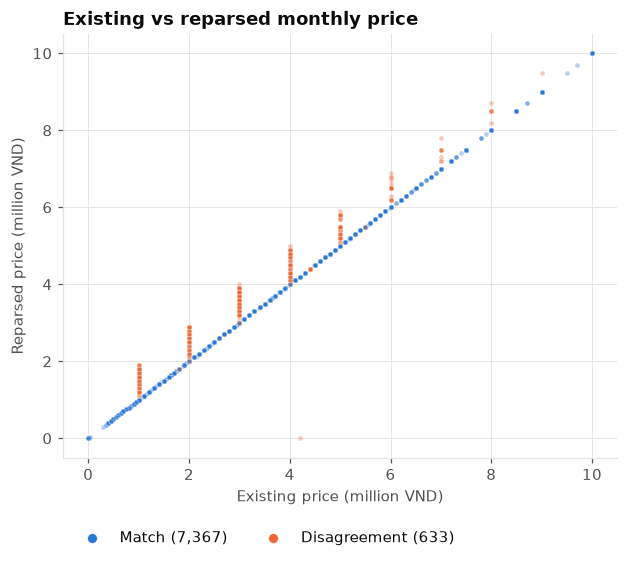

In [13]:
both = price_examples.loc[price_examples.existing.notna() & price_examples.reparsed.notna()].copy()
both["existing"] = pd.to_numeric(both.existing)
both["reparsed"] = pd.to_numeric(both.reparsed)
focus = both.loc[
    both.existing.le(both.existing.quantile(0.99)) & both.reparsed.le(both.reparsed.quantile(0.99))
]
focus = focus.sample(min(8000, len(focus)), random_state=42)

fig, ax = plt.subplots(figsize=(6.5, 5))
for label, mask, color in [
    ("Match", focus.price_parser_comparison_status.ne("DISAGREEMENT"), CATEGORICAL[0]),
    ("Disagreement", focus.price_parser_comparison_status.eq("DISAGREEMENT"), CATEGORICAL[1]),
]:
    ax.scatter(
        focus.existing[mask] / 1e6,
        focus.reparsed[mask] / 1e6,
        s=10,
        alpha=0.35,
        color=color,
        edgecolors="white",
        linewidths=0.3,
        label=f"{label} ({mask.sum():,})",
    )
ax.set(
    title="Existing vs reparsed monthly price",
    xlabel="Existing price (million VND)",
    ylabel="Reparsed price (million VND)",
)
ax.grid(axis="y")
scatter_legend(ax)
plt.show()

## 08. Area Validation

> **Why:** Apply the same lineage-safe validation to area evidence.

**Flow:** raw area evidence → existing area → reparsed area → `area_value_clean` + `area_quality_status`.

**Rule:** keep a positive existing area only with aligned lineage; recover only from a safe full-string area syntax that parses to a positive value.

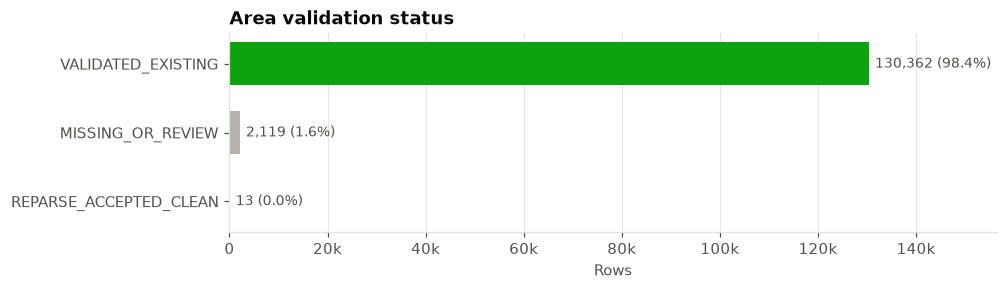

,Status,Rows,Percentage (%)
0,VALIDATED_EXISTING,130362,98.39
1,MISSING_OR_REVIEW,2119,1.60
2,REPARSE_ACCEPTED_CLEAN,13,0.01


,Rows,% of rows
Raw area available,130421,98.44
Existing area available,130362,98.39
Reparsed area,130406,98.42
Accepted reparse,13,0.01
Parser agreement,130349,98.38
Parser disagreement,1,0.00
Parse failure,12,0.01
Missing / review,2119,1.60


,Example category,source_code,rental_post_id,raw,existing,reparsed,final_clean,quality_status
0,Validated existing,mogi,53598,16 m 2 0 PN 0 WC,16.00,16.00,16.0,VALIDATED_EXISTING
1,Validated existing,mogi,53599,17 m 2 0 PN 0 WC,17.00,17.00,17.0,VALIDATED_EXISTING
2,Validated existing,mogi,53600,30 m 2 0 PN 0 WC,30.00,30.00,30.0,VALIDATED_EXISTING
41,Missing / review,chothuenha,53639,NaN,None,None,NaN,MISSING_OR_REVIEW
55,Missing / review,chothuenha,53653,NaN,None,None,NaN,MISSING_OR_REVIEW
67,Missing / review,chothuenha,53665,NaN,None,None,NaN,MISSING_OR_REVIEW
14864,Accepted reparse,chothuephongtro,74040,1000000 m 2,None,1000000.00,1000000.0,REPARSE_ACCEPTED_CLEAN
63271,Accepted reparse,chothuephongtro,159098,6000000 m 2,None,6000000.00,6000000.0,REPARSE_ACCEPTED_CLEAN
81303,Accepted reparse,chothuephongtro,189871,6500000 m 2,None,6500000.00,6500000.0,REPARSE_ACCEPTED_CLEAN


In [14]:
area_audit = numeric_audit_report(bronze_df, raw_evidence, silver_df, "area")
area_status = show_status(silver_df.area_quality_status, "Area validation status")
area_metrics = pd.Series(
    {
        "Raw area available": area_audit.raw.notna().sum(),
        "Existing area available": area_audit.existing.notna().sum(),
        "Reparsed area": area_audit.reparsed.notna().sum(),
        "Accepted reparse": area_audit.action.eq("REPARSE_ACCEPTED_CLEAN").sum(),
        "Parser agreement": area_audit.regression.eq("CANONICAL_MATCH").sum(),
        "Parser disagreement": area_audit.regression.eq("DIFFERENT_REVIEW").sum(),
        "Parse failure": area_audit.regression.eq("REPARSE_NULL").sum(),
        "Missing / review": silver_df.area_quality_status.isin(
            ["MISSING_OR_REVIEW", "UNKNOWN_LINEAGE"]
        ).sum(),
    },
    name="Rows",
).to_frame()
area_metrics["% of rows"] = (area_metrics.Rows / len(area_audit) * 100).round(2)
display(area_metrics)

area_examples = area_audit.assign(
    source_code=bronze_df.source_code, rental_post_id=bronze_df.rental_post_id
)
area_examples["Example category"] = np.select(
    [
        area_examples.action.eq("VALIDATED_EXISTING"),
        area_examples.action.eq("REPARSE_ACCEPTED_CLEAN"),
        area_examples.regression.eq("DIFFERENT_REVIEW"),
        area_examples.regression.eq("REPARSE_NULL"),
    ],
    ["Validated existing", "Accepted reparse", "Parser disagreement", "Parse failure"],
    default="Missing / review",
)
display(
    area_examples.groupby("Example category", group_keys=False).head(3)[
        [
            "Example category",
            "source_code",
            "rental_post_id",
            "raw",
            "existing",
            "reparsed",
            "final_clean",
            "quality_status",
        ]
    ]
)

## 09. Numeric Outlier Flags

> **Why:** Flag statistical tails without deleting or changing any value.

**Rule:** for each clean numeric field with at least four values and a positive IQR, flag values below `Q1 − 1.5×IQR` or above `Q3 + 1.5×IQR`. A flag is review evidence, not proof of an error.

,Metric,Threshold Method,Q1,Q3,Lower Threshold,Upper Threshold
0,Price,1.5 × IQR,3000000.0,5000000.0,0.0,8000000.0
1,Area,1.5 × IQR,22.0,35.0,2.5,54.5


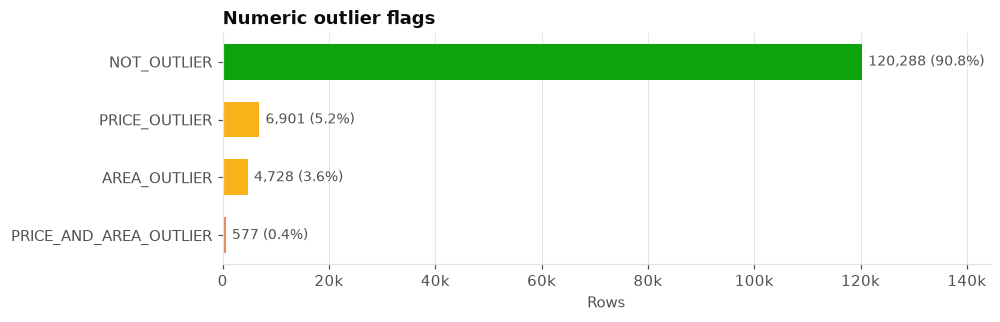

,Status,Rows,Percentage (%)
0,NOT_OUTLIER,120288,90.79
1,PRICE_OUTLIER,6901,5.21
2,AREA_OUTLIER,4728,3.57
3,PRICE_AND_AREA_OUTLIER,577,0.44


In [15]:
outlier_thresholds = pd.concat(
    [
        iqr_threshold_diagnostics(silver_df.price_amount_clean, "Price"),
        iqr_threshold_diagnostics(silver_df.area_value_clean, "Area"),
    ],
    ignore_index=True,
)
display(outlier_thresholds)
outlier_status = show_status(silver_df.numeric_outlier_status, "Numeric outlier flags")

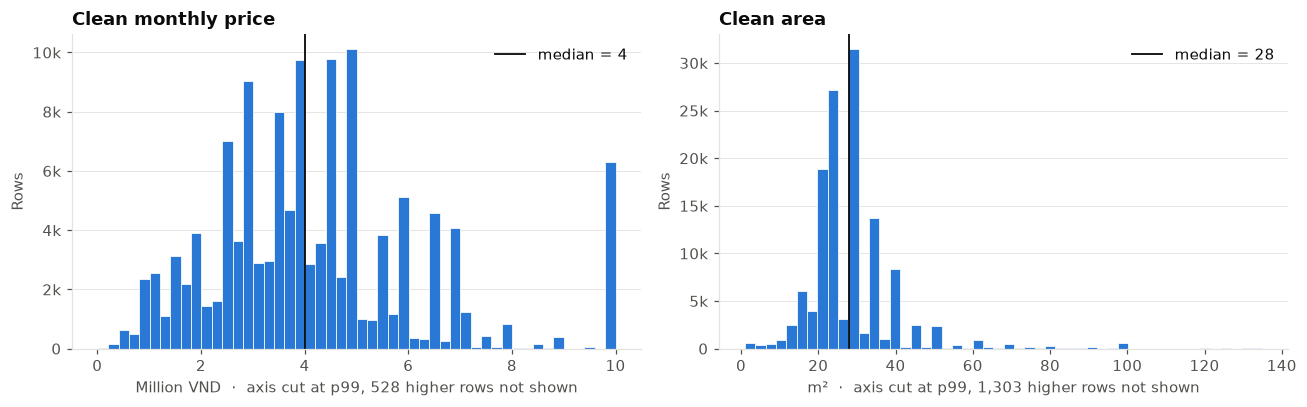

,rental_post_id,source_code,title_raw,price_amount_clean,area_value_clean,numeric_outlier_status
28,53626,mogi,Ktx phòng đẹp Phú Nhuận số lượng có hạn chỉ thừ 1tr5,1000000.0,80.0,AREA_OUTLIER
30,53628,mogi,Phú Nhuận Ký Túc Xá Tư Nhân Bao Trọn Chi Phí Chỉ Từ 1Tr6,1000000.0,120.0,AREA_OUTLIER
32,53630,mogi,"Quận 5, 10, Phú Nhuận Ký Túc Xá chỉ từ 1.000K",1000000.0,80.0,AREA_OUTLIER
34,53632,mogi,"Q.5, Q.10, Phú Nhuận ktx sinh viên chỉ từ 1.300.000 Đ/tháng",1000000.0,120.0,AREA_OUTLIER
35,53633,mogi,KTX hiện đại - tiện nghi trọn gói chỉ từ 1.500.000 đang nhiều ưu đãi,1000000.0,80.0,AREA_OUTLIER
37,53635,mogi,Ký túc xá Phú Nhuận 1tr6 sạch – tự do - thoải mái,1000000.0,120.0,AREA_OUTLIER
38,53636,mogi,Ktx Hiện Đại - Cao Cấp - Thuận Tiện Trung Tâm PN-Q10-Q5,1000000.0,80.0,AREA_OUTLIER
39,53637,mogi,Ktx Cao Cấp Phú Nhuận Bao Trọn Chi Phí 1TR6,1000000.0,120.0,AREA_OUTLIER
40,53638,mogi,"Chỉ từ 1.600.000 Giá Đã Bao Gồm Tất Cả Các Chi Phí, Không Phát Sinh",1000000.0,120.0,AREA_OUTLIER
46,53644,mogi,1PN ban công Ngã tư Phú Nhuận/ Phan xích Long/Nơ Trang Long/Bà Chiểu,10000000.0,30.0,PRICE_OUTLIER


In [16]:
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 3.8))
histogram(
    pd.to_numeric(silver_df.price_amount_clean, errors="coerce") / 1e6,
    title="Clean monthly price",
    xlabel="Million VND",
    ax=left,
)
histogram(silver_df.area_value_clean, title="Clean area", xlabel="m²", ax=right)
plt.tight_layout()
plt.show()
display(
    silver_df.loc[
        silver_df.numeric_outlier_status.ne("NOT_OUTLIER"),
        [
            "rental_post_id",
            "source_code",
            "title_raw",
            "price_amount_clean",
            "area_value_clean",
            "numeric_outlier_status",
        ],
    ].head(10)
)

## 10. Coordinate Trust Classification

> **Why:** Separate coordinate availability, validity, provider trust and repeated-point conflicts.

**Flow:** lat/lon → pair available? → finite, in range, non-zero? → trusted provider? → repeated point? → consistent address? → `coordinate_trust_reason`. No coordinate is ever inferred from a ward or district.

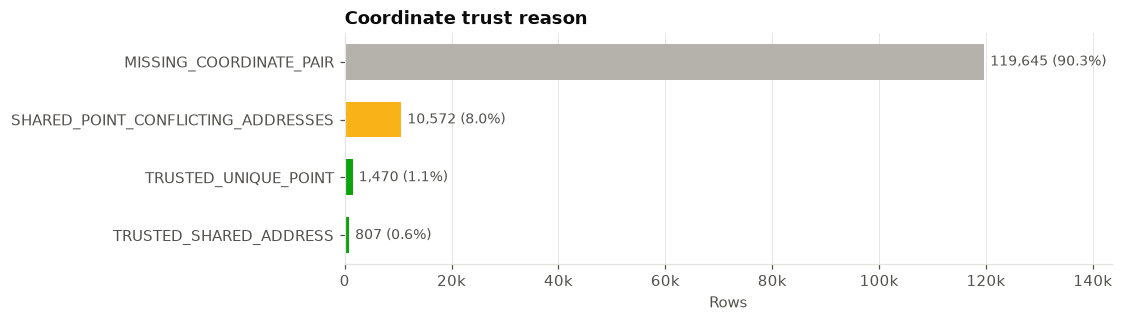

,Status,Rows,Percentage (%)
0,MISSING_COORDINATE_PAIR,119645,90.30
1,SHARED_POINT_CONFLICTING_ADDRESSES,10572,7.98
2,TRUSTED_UNIQUE_POINT,1470,1.11
3,TRUSTED_SHARED_ADDRESS,807,0.61


,Rows
Complete coordinate pairs,12849
Missing coordinate pairs,119645
Invalid range / non-finite / zero,0
Unique points,1470
Listings on a repeated point,11379
Largest repeated group,285
Trusted (usable),2277
Valid but untrusted,10572


In [17]:
coordinate_reason = show_status(silver_df.coordinate_trust_reason, "Coordinate trust reason")
coord_metrics = pd.Series(
    {
        "Complete coordinate pairs": (
            silver_df.map_latitude.notna() & silver_df.map_longitude.notna()
        ).sum(),
        "Missing coordinate pairs": silver_df.coordinate_trust_reason.eq(
            "MISSING_COORDINATE_PAIR"
        ).sum(),
        "Invalid range / non-finite / zero": silver_df.coordinate_trust_reason.isin(
            ["NONFINITE_COORDINATE", "OUT_OF_BOUNDS", "ZERO_COORDINATE"]
        ).sum(),
        "Unique points": silver_df.coordinate_pair_listing_count.eq(1).sum(),
        "Listings on a repeated point": silver_df.coordinate_pair_listing_count.gt(1).sum(),
        "Largest repeated group": silver_df.coordinate_pair_listing_count.max(),
        "Trusted (usable)": silver_df.has_trusted_coordinate.sum(),
        "Valid but untrusted": (
            ~silver_df.has_trusted_coordinate & silver_df.coordinate_pair_valid
        ).sum(),
    },
    name="Rows",
).to_frame()
display(coord_metrics)

Many listings share one exact point (often a district or agency pin). Those points are not trusted when the listings at them have different addresses:

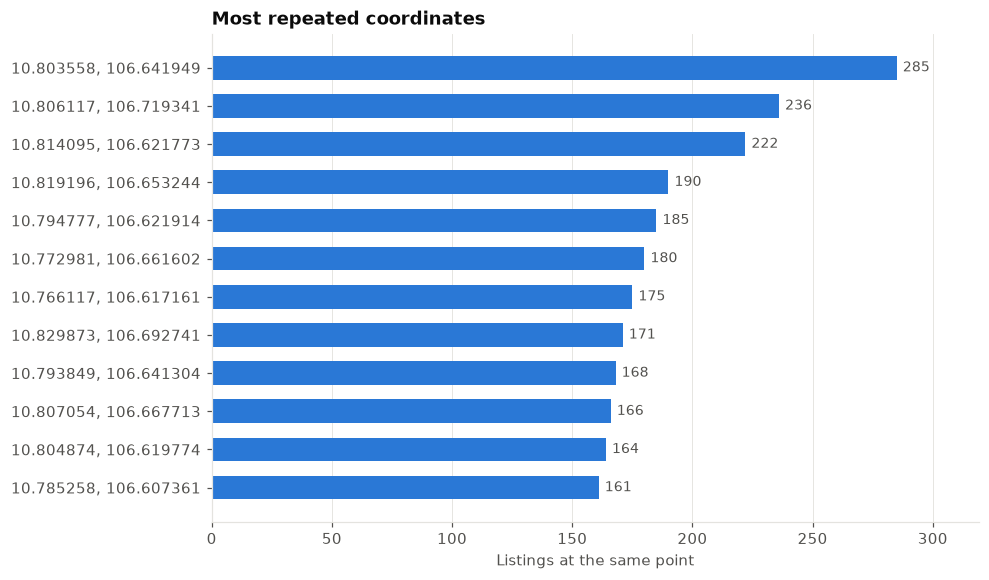

,Latitude,Longitude,Listings,Distinct_addresses,Distinct_wards,Distinct_sources
0,10.803558,106.641949,285,47,3,2
1,10.806117,106.719341,236,33,3,2
2,10.814095,106.621773,222,51,1,2
3,10.819196,106.653244,190,48,0,2
4,10.794777,106.621914,185,53,2,2
5,10.772981,106.661602,180,19,1,2
6,10.766117,106.617161,175,21,2,2
7,10.829873,106.692741,171,27,2,2
8,10.793849,106.641304,168,35,2,1
9,10.807054,106.667713,166,42,2,2


In [18]:
coord_groups = (
    silver_df.loc[silver_df.coordinate_pair_listing_count.gt(1)]
    .assign(
        Latitude=lambda x: x.map_latitude.round(6), Longitude=lambda x: x.map_longitude.round(6)
    )
    .groupby(["Latitude", "Longitude"], dropna=True)
    .agg(
        Listings=("rental_post_id", "size"),
        Distinct_addresses=("full_address_text", "nunique"),
        Distinct_wards=("ward_current", "nunique"),
        Distinct_sources=("source_code", "nunique"),
    )
    .reset_index()
    .sort_values("Listings", ascending=False)
)
top_coord = coord_groups.head(12).copy()
top_coord.index = top_coord.Latitude.astype(str) + ", " + top_coord.Longitude.astype(str)
bar_chart(
    top_coord.Listings, title="Most repeated coordinates", xlabel="Listings at the same point"
)
plt.show()
display(top_coord.reset_index(drop=True))

## 11. Cross-field Consistency (Price × Area)

> **Why:** Separate data availability from relationship-quality review.

**Rule:** `price_area_availability_status` says which of price/area exist. For available pairs, `price_area_quality_status` applies the price/area IQR flags, then a 1.5×IQR audit of price per m². `CHECKED_NO_FLAG` means these checks found nothing, not that the listing is certified.

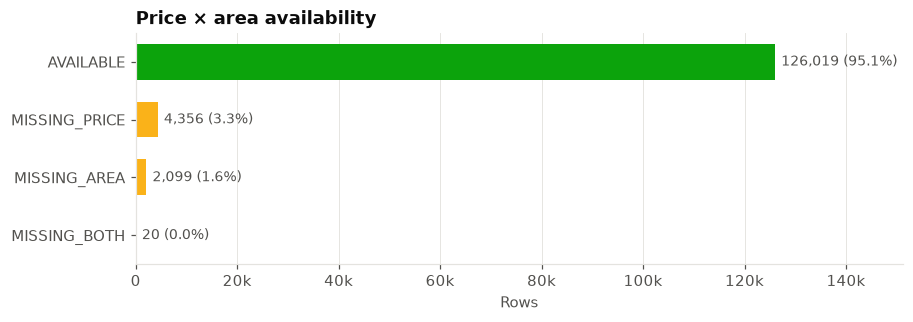

,Status,Rows,Percentage (%)
0,AVAILABLE,126019,95.11
1,MISSING_PRICE,4356,3.29
2,MISSING_AREA,2099,1.58
3,MISSING_BOTH,20,0.02


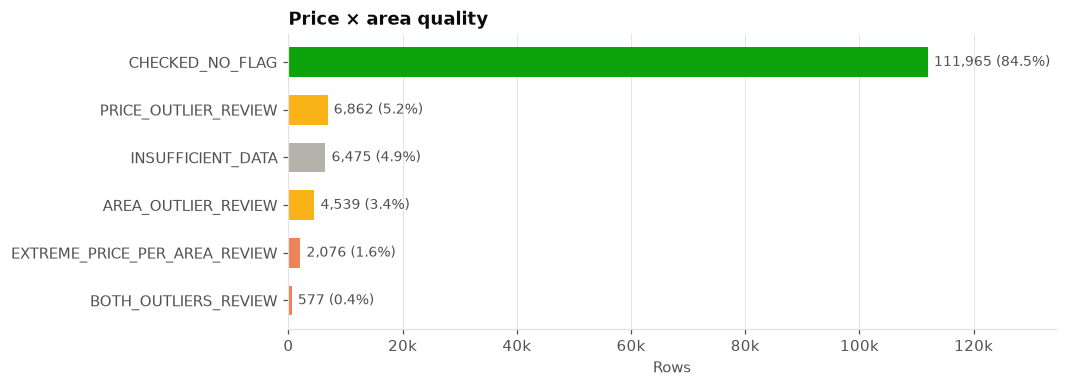

,Status,Rows,Percentage (%)
0,CHECKED_NO_FLAG,111965,84.51
1,PRICE_OUTLIER_REVIEW,6862,5.18
2,INSUFFICIENT_DATA,6475,4.89
3,AREA_OUTLIER_REVIEW,4539,3.43
4,EXTREME_PRICE_PER_AREA_REVIEW,2076,1.57
5,BOTH_OUTLIERS_REVIEW,577,0.44


,Metric,Threshold Method,Q1,Q3,Lower Threshold,Upper Threshold
0,Price per area audit,1.5 × IQR,113636.363636,192592.592593,-4797.979798,311026.936027


In [19]:
availability_status = show_status(
    silver_df.price_area_availability_status, "Price × area availability"
)
quality_status = show_status(silver_df.price_area_quality_status, "Price × area quality")

area_numeric = pd.to_numeric(silver_df.area_value_clean, errors="coerce")
price_per_area_audit = pd.to_numeric(
    silver_df.price_amount_clean, errors="coerce"
) / area_numeric.where(area_numeric.gt(0))
display(iqr_threshold_diagnostics(price_per_area_audit, "Price per area audit"))

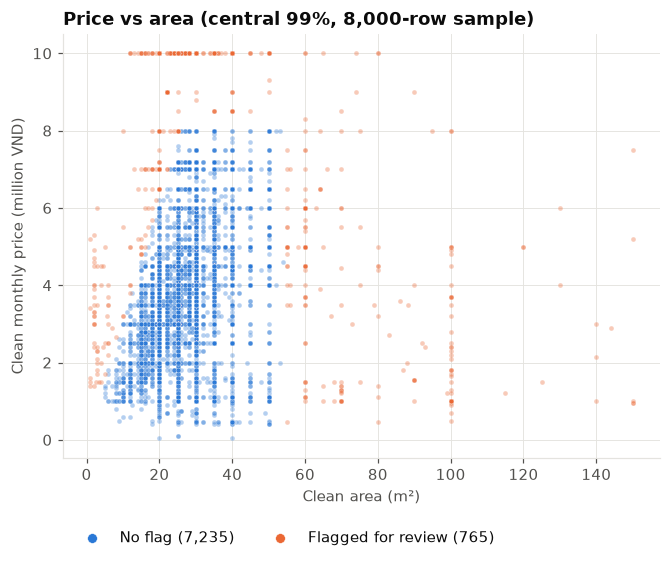

,title_clean,price_amount_clean,area_value_clean,price_per_area_audit,price_area_quality_status,source_code
19044,Cho thuê Phòng trọ Ký túc xá Lý Thường Kiệt Quận 11 – tiện nghi đầy đủ,950000.0,100.0,9500.000000,AREA_OUTLIER_REVIEW,mogi
12074,Ký Túc Xá Giá Rẻ Quận Phú Nhuận - Full Chi Phí - Giá Chỉ Từ 1tr500,1000000.0,100.0,10000.000000,AREA_OUTLIER_REVIEW,mogi
125954,"Phòng trọ tại Đường Huỳnh Tấn Phát, Quận 7 đầy đủ tiện nghi cao cấp giá 4tr1/tháng",10000000.0,25.0,400000.000000,PRICE_OUTLIER_REVIEW,chothuephongtro
126166,"Phòng đẹp siêu đẹp,full nội thất,ban công view đẹp tại trung tâm Quận 3 đường Võ Thị Sáu",10000000.0,24.0,416666.666667,PRICE_OUTLIER_REVIEW,chothuephongtro
121748,Duplex mới đang được free phí ngay Crescent Mall Quận 7,10000000.0,35.0,285714.285714,PRICE_OUTLIER_REVIEW,chothuephongtro
6531,KHAI TRƯƠNG COMPACT MINIDUPLEX (CENTER CITYLAND GÒ VẤP) CỰC XỊN XÒ - BAO HẾT CP - NGAY...,2200000.0,100.0,22000.000000,AREA_OUTLIER_REVIEW,phongtro123
127217,"Phòng trọ tại 127/46/2 Thới An 13, Quận 12 giá thuê 1tr3/tháng phòng rộng rãi có gác lững",7000000.0,16.0,437500.000000,EXTREME_PRICE_PER_AREA_REVIEW,chothuephongtro
97739,"Cho thuê or Nhượng lại 1 Phòng CHDV Full nội thất tại Lý Chính Thắng, Q.3 Mr Khang",8000000.0,25.0,320000.000000,EXTREME_PRICE_PER_AREA_REVIEW,phongtro123
32805,Top phòng cho thuê rẻ 15m2 full nội thất Nơ Trang Long Bình Thạnh TP.HCM,4800000.0,15.0,320000.000000,EXTREME_PRICE_PER_AREA_REVIEW,phongtro123
96013,"Cho thuê nguyên căn tầng 1- (gồm 3 phòng)- Phan Đăng Lưu, Phú Nhuận",8500000.0,70.0,121428.571429,BOTH_OUTLIERS_REVIEW,phongtro123


In [20]:
pa = silver_df.assign(price_per_area_audit=price_per_area_audit).loc[
    silver_df.price_area_availability_status.eq("AVAILABLE")
]
pa = pa.loc[
    pa.area_value_clean.le(pa.area_value_clean.quantile(0.99))
    & pa.price_amount_clean.le(pa.price_amount_clean.quantile(0.99))
]
pa = pa.sample(min(8000, len(pa)), random_state=42)
flagged = pa.price_area_quality_status.ne("CHECKED_NO_FLAG")

fig, ax = plt.subplots(figsize=(7, 5))
for label, mask, color in [
    ("No flag", ~flagged, CATEGORICAL[0]),
    ("Flagged for review", flagged, CATEGORICAL[1]),
]:
    ax.scatter(
        pa.area_value_clean[mask],
        pa.price_amount_clean[mask] / 1e6,
        s=10,
        alpha=0.35,
        color=color,
        edgecolors="white",
        linewidths=0.3,
        label=f"{label} ({mask.sum():,})",
    )
ax.set(
    title="Price vs area (central 99%, 8,000-row sample)",
    xlabel="Clean area (m²)",
    ylabel="Clean monthly price (million VND)",
)
ax.grid(axis="y")
scatter_legend(ax)
plt.show()
display(
    pa.loc[
        flagged,
        [
            "title_clean",
            "price_amount_clean",
            "area_value_clean",
            "price_per_area_audit",
            "price_area_quality_status",
            "source_code",
        ],
    ]
    .groupby("price_area_quality_status", group_keys=False)
    .head(3)
)

## 12. Duplicate / Repost Candidate Hardening

> **Why:** Find likely reposts without fuzzy matching, merging, or deleting rows.

**Rules (any one links two listings):**
1. `EXACT_FINGERPRINT` — same normalized title, address, clean price and clean area.
2. `SAME_ADDRESS_PRICE_AREA` — cross-source only; same address, price and area.
3. `SAME_TITLE_PRICE_WARD` — cross-source only; same title, price and current ward.

Links form deterministic connected components. `POSSIBLE_DUPLICATE` is a candidate, never a confirmation; missing values and shared coordinates alone are not evidence.

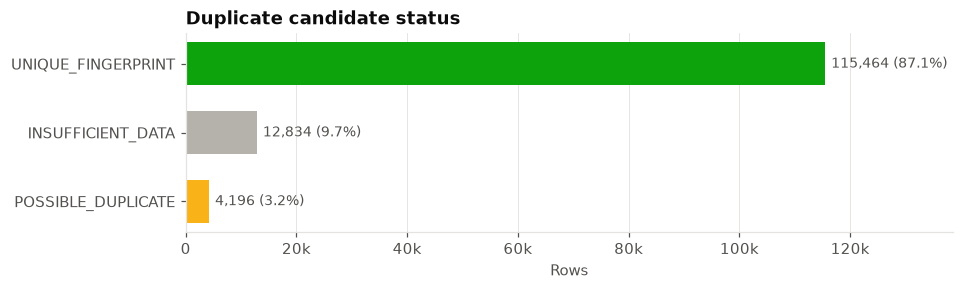

,Status,Rows,Percentage (%)
0,UNIQUE_FINGERPRINT,115464,87.15
1,INSUFFICIENT_DATA,12834,9.69
2,POSSIBLE_DUPLICATE,4196,3.17


,value
Candidate groups,1064
Candidate listings,4196
Largest group,66
Same-source groups,996
Cross-source groups,68


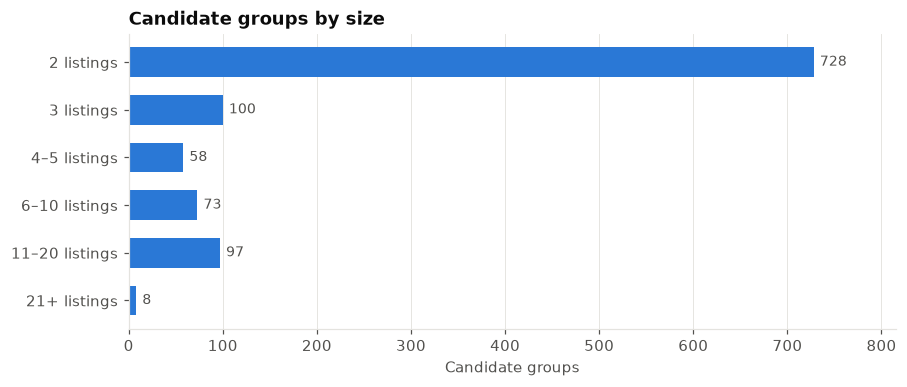

In [21]:
duplicate_status = show_status(silver_df.duplicate_candidate_status, "Duplicate candidate status")
duplicate_groups, duplicate_distribution = duplicate_group_summary(silver_df)
display(
    pd.Series(
        {
            "Candidate groups": len(duplicate_groups),
            "Candidate listings": int(
                silver_df.duplicate_candidate_status.eq("POSSIBLE_DUPLICATE").sum()
            ),
            "Largest group": int(duplicate_groups.Listings.max()) if len(duplicate_groups) else 0,
            "Same-source groups": int(duplicate_groups["Candidate Scope"].eq("Same-source").sum()),
            "Cross-source groups": int(
                duplicate_groups["Candidate Scope"].eq("Cross-source").sum()
            ),
        },
        name="value",
    ).to_frame()
)
if len(duplicate_distribution):
    size_band = pd.cut(
        duplicate_distribution["Group Size"],
        bins=[1, 2, 3, 5, 10, 20, np.inf],
        labels=[
            "2 listings",
            "3 listings",
            "4–5 listings",
            "6–10 listings",
            "11–20 listings",
            "21+ listings",
        ],
    )
    bar_chart(
        duplicate_distribution.groupby(size_band, observed=True)["Candidate Groups"].sum(),
        title="Candidate groups by size",
        xlabel="Candidate groups",
        sort=False,
    )
    plt.show()

In [22]:
for scope_name in ["SAME_SOURCE", "CROSS_SOURCE"]:
    ids = (
        silver_df.loc[silver_df.duplicate_scope.eq(scope_name), "duplicate_candidate_group"]
        .dropna()
        .drop_duplicates()
        .head(3)
    )
    sample = silver_df.loc[
        silver_df.duplicate_candidate_group.isin(ids),
        [
            "duplicate_candidate_group",
            "duplicate_match_reason",
            "source_code",
            "title_clean",
            "price_amount_clean",
            "area_value_clean",
            "best_address_text_clean",
            "ward_current",
        ],
    ]
    display(Markdown(f"**{scope_name.replace('_', ' ').title()} examples**"))
    display(sample)

**Same Source examples**

,duplicate_candidate_group,duplicate_match_reason,source_code,title_clean,price_amount_clean,area_value_clean,best_address_text_clean,ward_current
15,CANDIDATE:b3fd114d287f998c,EXACT_FINGERPRINT,mogi,"Ký túc xá tiện nghi đi bộ 5 phút đến ĐH Y Dược, BV Chợ Rẫy",1000000.0,45.0,"Nguyễn Kim, Phường 12, Quận 5, TPHCM",Phường Chợ Lớn
25,CANDIDATE:b3fd114d287f998c,EXACT_FINGERPRINT,mogi,"Ký túc xá tiện nghi đi bộ 5 phút đến ĐH Y Dược, BV Chợ Rẫy",1000000.0,45.0,"Nguyễn Kim, Phường 12, Quận 5, TPHCM",Phường Chợ Lớn
655,CANDIDATE:a6d94dea06fc1ec2,EXACT_FINGERPRINT,cafeland,Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ:,6000000.0,63.0,Dĩ An TP. Hồ Chí Minh,NaN
656,CANDIDATE:e3c231dfd7d3fff5,EXACT_FINGERPRINT,cafeland,Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ:,3500000.0,30.0,Cát Lái TP. Hồ Chí Minh,NaN
665,CANDIDATE:a6d94dea06fc1ec2,EXACT_FINGERPRINT,cafeland,Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ:,6000000.0,63.0,Dĩ An TP. Hồ Chí Minh,NaN
669,CANDIDATE:e3c231dfd7d3fff5,EXACT_FINGERPRINT,cafeland,Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ:,3500000.0,30.0,Cát Lái TP. Hồ Chí Minh,NaN
3467,CANDIDATE:a6d94dea06fc1ec2,EXACT_FINGERPRINT,cafeland,Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ:,6000000.0,63.0,Dĩ An TP. Hồ Chí Minh,NaN
3468,CANDIDATE:a6d94dea06fc1ec2,EXACT_FINGERPRINT,cafeland,Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ:,6000000.0,63.0,Dĩ An TP. Hồ Chí Minh,NaN
3533,CANDIDATE:a6d94dea06fc1ec2,EXACT_FINGERPRINT,cafeland,Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ: Cho thuê phòng trọ:,6000000.0,63.0,Dĩ An TP. Hồ Chí Minh,NaN


**Cross Source examples**

,duplicate_candidate_group,duplicate_match_reason,source_code,title_clean,price_amount_clean,area_value_clean,best_address_text_clean,ward_current
285,CANDIDATE:5f362d4f6ee5022f,SAME_TITLE_PRICE_WARD,chothuenha,"PHÒNG 30M2 - BANCOL LỚN - LẦU 1 - FULL NỘI THẤT- NGAY BÀ HẠT VS NGUYỄN TRI PHƯƠNG - 6,...",6500000.0,NaN,"450 Đường Nguyễn Tri Phương, Phường 4, Quận 10, Hồ Chí Minh",Phường Vườn Lài
411,CANDIDATE:0a11f712868b5b28,SAME_TITLE_PRICE_WARD,chothuenha,CHO THUÊ PHÒNG TRỌ TRUNG TÂM Q10,3600000.0,NaN,"Đường Cao Thắng, Phường 12, Quận 10, Hồ Chí Minh",Phường Hòa Hưng
417,CANDIDATE:9a1571fa268ec0f5,SAME_TITLE_PRICE_WARD,chothuenha,SANG HỢP ĐỒNG PHÒNG TRỌ 35M² – VIEW LANDMARK 81 – TRẦN NÃO Q2,6300000.0,NaN,"6G20 Đường Trần Não, Phường An Khánh, Quận 2, Hồ Chí Minh",Phường An Khánh
5118,CANDIDATE:5f362d4f6ee5022f,SAME_TITLE_PRICE_WARD,phongtro123,"PHÒNG 30M2 - BANCOL LỚN - LẦU 1 - FULL NỘI THẤT- NGAY BÀ HẠT VS NGUYỄN TRI PHƯƠNG - 6,...",6500000.0,30.0,"426 Đường Nguyễn Tri Phương, Phường Vườn Lài, Hồ Chí Minh",Phường Vườn Lài
6380,CANDIDATE:0a11f712868b5b28,SAME_TITLE_PRICE_WARD,phongtro123,CHO THUÊ PHÒNG TRỌ TRUNG TÂM Q10,3600000.0,20.0,"232/36 Đường Cao Thắng, Phường Hòa Hưng, Hồ Chí Minh",Phường Hòa Hưng
7596,CANDIDATE:9a1571fa268ec0f5,SAME_TITLE_PRICE_WARD,phongtro123,SANG HỢP ĐỒNG PHÒNG TRỌ 35M² – VIEW LANDMARK 81 – TRẦN NÃO Q2,6300000.0,35.0,"6G20 Đường Trần Não, Phường An Khánh, Hồ Chí Minh",Phường An Khánh


## 13. Temporal Semantics Validation

> **Why:** Flag timestamp orderings that cannot be explained by current evidence.

**Rule:** a missing timestamp → `INSUFFICIENT_DATA`; `first > last`, `latest < first` or `latest > last` → `REQUIRES_REVIEW`; otherwise `VALID`. The cause is not inferred.

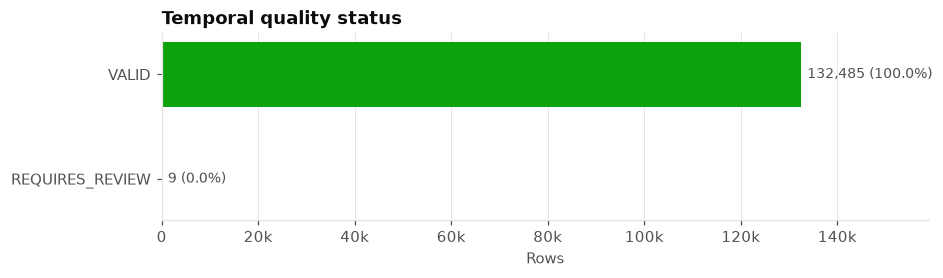

,Status,Rows,Percentage (%)
0,VALID,132485,99.99
1,REQUIRES_REVIEW,9,0.01


,rental_post_id,source_code,first_observed_at,last_observed_at,latest_observed_at,active_days
736,54334,nhatot,2026-09-20 12:48:36,2026-09-21 12:35:16,2026-09-21 12:41:24,1
3858,60485,mogi,2026-09-20 13:15:50,2026-09-22 02:55:15,2026-09-22 03:00:15,2
55240,131725,nhatot,2026-09-21 13:50:28,2026-09-22 12:42:07,2026-09-22 12:46:54,1
86448,204777,nhatot,2026-09-21 23:37:48,2026-09-22 12:42:07,2026-09-22 12:46:19,1
118143,268487,nhatot,2026-09-22 12:46:42,2026-09-22 12:42:07,2026-09-22 12:46:42,0
118145,268491,nhatot,2026-09-22 12:46:51,2026-09-22 12:42:07,2026-09-22 12:46:51,0
118146,268493,nhatot,2026-09-22 12:46:57,2026-09-22 12:42:07,2026-09-22 12:46:57,0
118147,268494,nhatot,2026-09-22 12:47:02,2026-09-22 12:42:07,2026-09-22 12:47:02,0
118148,268495,nhatot,2026-09-22 12:47:03,2026-09-22 12:42:07,2026-09-22 12:47:03,0


In [23]:
temporal_status = show_status(silver_df.temporal_quality_status, "Temporal quality status")
display(
    silver_df.loc[
        silver_df.temporal_quality_status.eq("REQUIRES_REVIEW"),
        [
            "rental_post_id",
            "source_code",
            "first_observed_at",
            "last_observed_at",
            "latest_observed_at",
            "active_days",
        ],
    ].head(15)
)

## 14. Final Row Quality Status

> **Why:** Roll the flags up per row without turning them into a score.

**Rule:** `REQUIRES_REVIEW` only for an unusable title, temporal review, or ambiguous ward mapping. `READY_WITH_FLAGS` = no critical condition but at least one flag or unavailable field. `READY` = no flag at all.

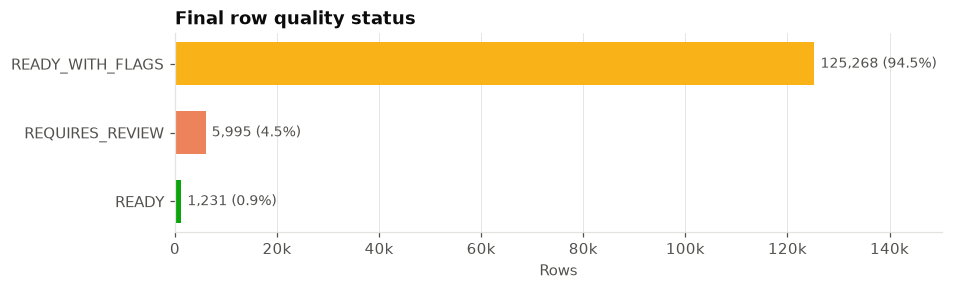

,Status,Rows,Percentage (%)
0,READY_WITH_FLAGS,125268,94.55
1,REQUIRES_REVIEW,5995,4.52
2,READY,1231,0.93


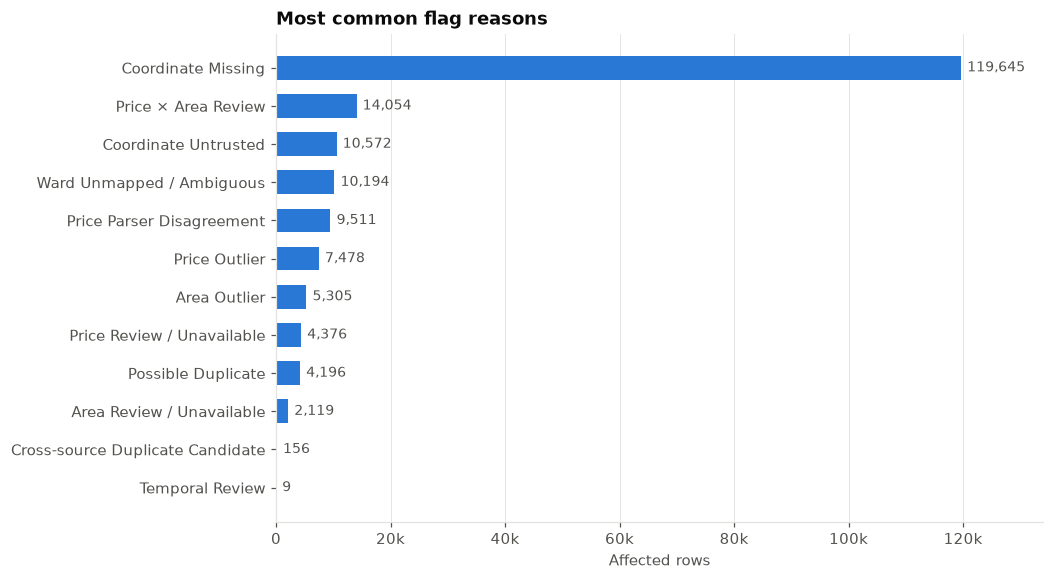

In [24]:
row_status = show_status(silver_df.row_quality_status, "Final row quality status")
flag_breakdown, flag_matrix = flag_reason_breakdown(silver_df)
bar_chart(
    flag_breakdown.head(12).set_index("Flag Reason")["Affected Rows"],
    title="Most common flag reasons",
    xlabel="Affected rows",
)
plt.show()

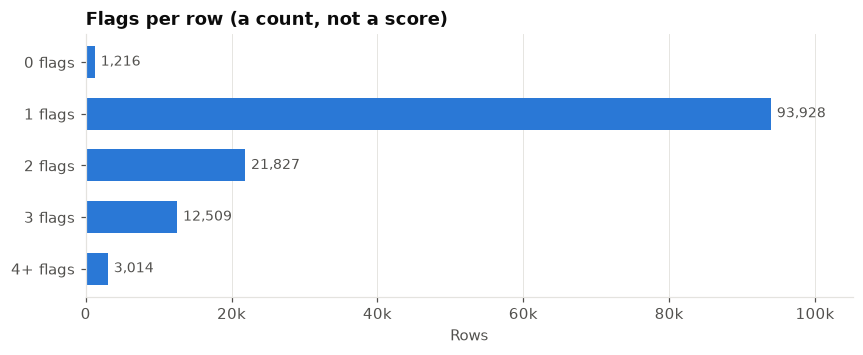

In [25]:
flag_distribution = multi_flag_distribution(flag_matrix)
bar_chart(
    flag_distribution.set_index(flag_distribution["Flag Count"].astype(str) + " flags")["Rows"],
    title="Flags per row (a count, not a score)",
    sort=False,
)
plt.show()

## 15. Silver Dataset Contract & Lineage

> **Why:** Make every output field and a few representative row traces readable.

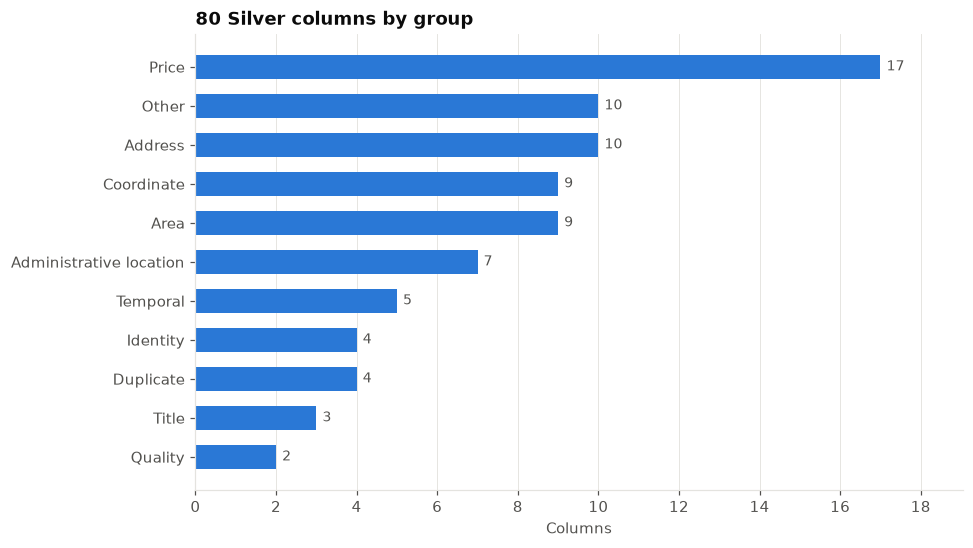

,Group,Field,Kind,Origin,Nullable
15,Address,best_address_source,Raw,Bronze snapshot,No
14,Address,best_address_text,Raw,Bronze snapshot,Yes
22,Address,best_address_text_clean,Clean / derived,Silver helper,Yes
68,Address,coordinate_pair_address_count,Clean / derived,Silver helper,No
9,Address,full_address_inherited,Raw,Bronze snapshot,No
...,...,...,...,...,...
16,Temporal,latest_observed_at,Raw,Bronze snapshot,No
78,Temporal,temporal_quality_status,Status,Silver helper,No
23,Title,title_clean,Clean / derived,Silver helper,Yes
24,Title,title_quality_status,Status,Silver helper,No


In [26]:
FIELD_GROUPS = [
    ("Identity", lambda f: f in {"source_code", "rental_post_id", "source_listing_id", "url"}),
    ("Title", lambda f: "title" in f),
    ("Price", lambda f: "price" in f),
    ("Area", lambda f: "area" in f),
    (
        "Address",
        lambda f: "address" in f
        or f in {"location_raw", "full_address_inherited", "street_text_extracted", "parse_status"},
    ),
    ("Administrative location", lambda f: any(k in f for k in ("ward", "district", "province"))),
    ("Coordinate", lambda f: f.startswith("map_") or "coordinate" in f),
    ("Duplicate", lambda f: "duplicate" in f),
    ("Temporal", lambda f: "observed" in f or f == "active_days" or "temporal" in f),
    ("Quality", lambda f: "quality" in f or "outlier" in f),
    ("Lineage", lambda f: "lineage" in f or "regression" in f),
]


def field_group(field):
    return next((group for group, matches in FIELD_GROUPS if matches(field)), "Other")


def field_kind(field):
    if field in BRONZE_COLUMNS:
        return "Raw"
    if field.endswith(("_status", "_flag")) or field in {"parse_status", "has_trusted_coordinate"}:
        return "Status"
    return "Clean / derived"


silver_contract = pd.DataFrame(
    [
        {
            "Group": field_group(field),
            "Field": field,
            "Kind": field_kind(field),
            "Origin": "Bronze snapshot" if field in BRONZE_COLUMNS else "Silver helper",
            "Nullable": "Yes" if silver_df[field].isna().any() else "No",
        }
        for field in silver_df.columns
    ]
).sort_values(["Group", "Field"])
bar_chart(
    silver_contract.groupby("Group").size(),
    title=f"{len(silver_contract)} Silver columns by group",
    xlabel="Columns",
)
plt.show()
display(silver_contract)

In [27]:
selectors = [
    ("Normal clean", silver_df.row_quality_status.eq("READY")),
    ("Price reparse", silver_df.price_quality_status.eq("REPARSE_ACCEPTED_CLEAN")),
    ("Ward mapped", silver_df.ward_mapping_status.eq("MAPPED")),
    ("Coordinate review", ~silver_df.has_trusted_coordinate),
    ("Duplicate candidate", silver_df.duplicate_candidate_status.eq("POSSIBLE_DUPLICATE")),
    ("Temporal review", silver_df.temporal_quality_status.eq("REQUIRES_REVIEW")),
]
chosen = {}
for label, mask in selectors:
    candidate = next((idx for idx in silver_df.index[mask] if idx not in chosen.values()), None)
    if candidate is not None:
        chosen[label] = candidate

lineage = silver_df.loc[
    list(chosen.values()),
    [
        "rental_post_id",
        "source_code",
        "title_raw",
        "title_clean",
        "price_amount",
        "price_amount_clean",
        "area_value",
        "area_value_clean",
        "best_address_text",
        "ward_current",
        "coordinate_trust_reason",
        "duplicate_candidate_status",
        "row_quality_status",
    ],
]
lineage.insert(0, "Example", list(chosen))
display(Markdown("**Raw → Silver lineage examples**"))
display(lineage)

**Raw → Silver lineage examples**

,Example,rental_post_id,source_code,title_raw,title_clean,price_amount,price_amount_clean,area_value,area_value_clean,best_address_text,ward_current,coordinate_trust_reason,duplicate_candidate_status,row_quality_status
71,Normal clean,53669,cafeland,Cho Thuê Phòng Cao Cấp Đầy Đủ Tiện Nghi Tại Q9 2tr7,Cho Thuê Phòng Cao Cấp Đầy Đủ Tiện Nghi Tại Q9 2tr7,2700000.0,2.700000e+06,18.0,18.0,"25/16/1, , Tăng Nhơn Phú TP. Hồ Chí Minh",Phường Tăng Nhơn Phú,TRUSTED_UNIQUE_POINT,UNIQUE_FINGERPRINT,READY
36966,Price reparse,99659,cafeland,"Phòng trọ: Bán nhà MT Nguyễn Đình Chiểu P, 6 Quận 3, dt:20x18m giá 275 tỷ","Phòng trọ: Bán nhà MT Nguyễn Đình Chiểu P, 6 Quận 3, dt:20x18m giá 275 tỷ",NaN,2.750000e+11,330.0,330.0,Xuân Hòa TP. Hồ Chí Minh,NaN,SHARED_POINT_CONFLICTING_ADDRESSES,UNIQUE_FINGERPRINT,READY_WITH_FLAGS
1,Ward mapped,53599,mogi,Cho Thuê Phòng Q3.đầy đủ nội thất.cửa sổ ban công.3tr3,Cho Thuê Phòng Q3.đầy đủ nội thất.cửa sổ ban công.3tr3,3000000.0,3.000000e+06,17.0,17.0,"Nguyễn Thiện Thuật, Phường 3, Quận 3, TPHCM",Phường Bàn Cờ,MISSING_COORDINATE_PAIR,UNIQUE_FINGERPRINT,READY_WITH_FLAGS
0,Coordinate review,53598,mogi,Cho Thuê Phòng Q3 rộng rãi thoải mái.cửa sổ nội thất 3tr1,Cho Thuê Phòng Q3 rộng rãi thoải mái.cửa sổ nội thất 3tr1,3000000.0,3.000000e+06,16.0,16.0,"Lý Chính Thắng, Phường 7 (Phường Võ Thị Sáu), Quận 3, TPHCM",NaN,SHARED_POINT_CONFLICTING_ADDRESSES,UNIQUE_FINGERPRINT,READY_WITH_FLAGS
15,Duplicate candidate,53613,mogi,"Ký túc xá tiện nghi đi bộ 5 phút đến ĐH Y Dược, BV Chợ Rẫy","Ký túc xá tiện nghi đi bộ 5 phút đến ĐH Y Dược, BV Chợ Rẫy",1000000.0,1.000000e+06,45.0,45.0,"Nguyễn Kim, Phường 12, Quận 5, TPHCM",Phường Chợ Lớn,SHARED_POINT_CONFLICTING_ADDRESSES,POSSIBLE_DUPLICATE,READY_WITH_FLAGS
736,Temporal review,54334,nhatot,NaN,None,4500000.0,4.500000e+06,20.0,20.0,"duong So 17, Phường 11, Quận Gò Vấp, Tp Hồ Chí Minh",Phường Thông Tây Hội,MISSING_COORDINATE_PAIR,UNIQUE_FINGERPRINT,REQUIRES_REVIEW


### Semantic suitability & model eligibility audit

The same suitability contract Notebook 04 uses, made visible here so eligibility can be diagnosed
without running the model notebook.

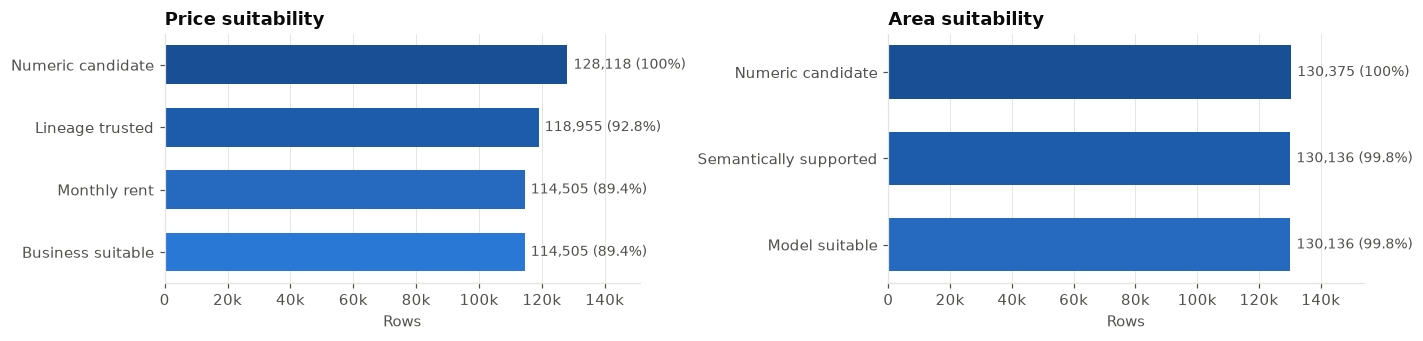

In [28]:
price_num = pd.to_numeric(silver_df.price_amount_clean, errors="coerce").gt(
    0
) & ~silver_df.price_quality_status.eq("MISSING_OR_REVIEW")
price_lineage = (
    price_num
    & silver_df.price_target_trust_status.isin({"TRUSTED_EXISTING", "TRUSTED_REPARSED"})
    & pd.to_numeric(silver_df.price_model_value, errors="coerce").gt(0)
)
price_semantic = price_lineage & silver_df.price_semantic_status.eq("SUPPORTED_MONTHLY_RENT")
price_suitable = price_lineage & silver_df.price_model_suitability.eq("SUPPORTED")

area_num = pd.to_numeric(silver_df.area_value_clean, errors="coerce").gt(
    0
) & ~silver_df.area_quality_status.eq("MISSING_OR_REVIEW")
area_semantic = area_num & silver_df.area_semantic_status.isin(
    {"EXISTING_NUMERIC", "EXPLICIT_AREA", "DERIVED_FROM_DIMENSIONS", "SUPPORTED_EXISTING_NUMERIC"}
)
area_suitable = area_num & silver_df.area_model_suitability.eq("SUPPORTED")

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 3.2))
funnel_chart(
    pd.Series(
        {
            "Numeric candidate": price_num.sum(),
            "Lineage trusted": price_lineage.sum(),
            "Monthly rent": price_semantic.sum(),
            "Business suitable": price_suitable.sum(),
        }
    ),
    title="Price suitability",
    ax=left,
)
funnel_chart(
    pd.Series(
        {
            "Numeric candidate": area_num.sum(),
            "Semantically supported": area_semantic.sum(),
            "Model suitable": area_suitable.sum(),
        }
    ),
    title="Area suitability",
    ax=right,
)
plt.tight_layout()
plt.show()

**Listing intent × rental scope**

rental_scope,MULTI_UNIT_BUSINESS,SINGLE_OR_ORDINARY_UNIT,UNKNOWN,WHOLE_BUILDING,Total
listing_intent,,,,,
RENT,84,91947,0,1,92032
SALE,2,0,22,0,24
TRANSFER,12,853,0,1,866
UNKNOWN,104,0,39467,1,39572
Total,202,92800,39489,3,132494


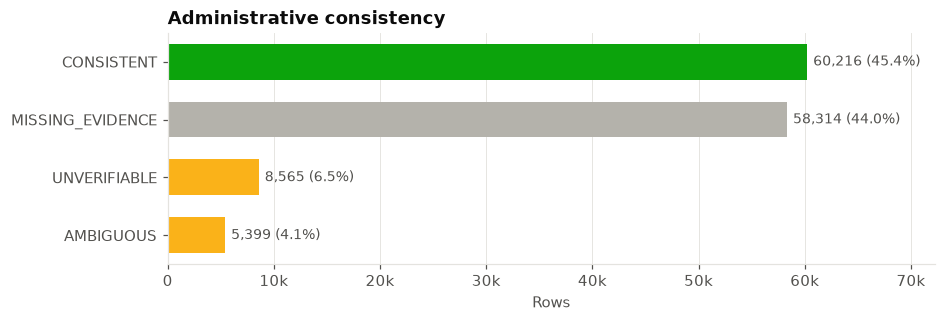

,Status,Rows,Percentage (%)
0,CONSISTENT,60216,45.45
1,MISSING_EVIDENCE,58314,44.01
2,UNVERIFIABLE,8565,6.46
3,AMBIGUOUS,5399,4.07


In [29]:
display(Markdown("**Listing intent × rental scope**"))
display(
    pd.crosstab(
        silver_df.listing_intent.fillna("MISSING"),
        silver_df.rental_scope.fillna("MISSING"),
        margins=True,
        margins_name="Total",
    )
)
admin_status = show_status(silver_df.admin_consistency_status, "Administrative consistency")

## 16. Pre-Silver Quality Gate

> **Why:** Stop publication when grain, identity, lineage, clean-value or status invariants fail.

Every invariant below must pass; the `assert` is authoritative.

In [30]:
quality_gate = evaluate_pre_silver_quality_gate(RAW_FINGERPRINT, silver_df)
protections = {
    "row_count_preserved": "Silent row deletion",
    "rental_post_id_non_null": "Identity completeness",
    "rental_post_id_unique": "One-row grain",
    "source_identity_preserved": "Source identity",
    "raw_source_fields_unchanged": "Bronze/source lineage",
    "no_row_multiplication_or_deletion": "Join cardinality",
    "price_clean_contract_valid": "Price acceptance rules",
    "area_clean_contract_valid": "Area acceptance rules",
    "ambiguous_ward_not_truth": "Guessed administrative mapping",
    "invalid_coordinates_not_usable": "Spatial trust",
    "outliers_preserved_and_flagged": "Silent outlier deletion",
    "duplicate_candidates_preserved_and_flagged": "Silent candidate deletion",
    "price_parser_disagreement_preserved": "Hidden parser disagreements",
    "price_area_status_domain_valid": "Price × area status vocabulary",
    "duplicate_scope_domain_valid": "Duplicate scope vocabulary",
    "duplicate_candidate_rows_preserved": "Candidate-driven row deletion",
    "cross_source_duplicate_rule_deterministic": "Cross-source rule semantics",
    "documented_status_values_only": "Status contract",
    "semantic_decisions_auditable": "Unexplained semantic decisions",
    "price_target_trust_domain_valid": "Price trust vocabulary",
    "price_target_trust_reason_evidence_consistent": "Trust reasons without evidence",
    "no_trusted_missing_target": "Trusted rows without a target",
    "trusted_reparsed_has_evidence": "Reparsed trust without raw evidence",
    "untrusted_has_no_model_value": "Untrusted prices reaching the model",
}
gate = quality_gate.to_frame().rename(columns={"invariant": "Invariant", "passed": "Passed"})
assert gate.Invariant.isin(protections).all(), "Describe every quality-gate invariant"
gate["Result"] = np.where(gate.Passed, "PASS", "FAIL")
gate["Protects against"] = gate.Invariant.map(protections)
passed = int(gate.Passed.sum())
display(Markdown(f"### Quality gate: **{passed} / {len(gate)} invariants PASS**"))
display(gate[["Invariant", "Result", "Protects against"]])
assert quality_gate.passed

### Quality gate: **24 / 24 invariants PASS**

,Invariant,Result,Protects against
0,row_count_preserved,PASS,Silent row deletion
1,rental_post_id_non_null,PASS,Identity completeness
2,rental_post_id_unique,PASS,One-row grain
3,source_identity_preserved,PASS,Source identity
4,raw_source_fields_unchanged,PASS,Bronze/source lineage
5,no_row_multiplication_or_deletion,PASS,Join cardinality
6,price_clean_contract_valid,PASS,Price acceptance rules
7,area_clean_contract_valid,PASS,Area acceptance rules
8,ambiguous_ward_not_truth,PASS,Guessed administrative mapping
9,invalid_coordinates_not_usable,PASS,Spatial trust


## 17. Compare with Published Canonical Silver

> **Why:** Prove the file published by Airflow equals this notebook's rebuild of the same snapshot.

```text
roombeacon_bronze_snapshot (Airflow, bounded MySQL read)
    ↓ Asset: bronze_snapshot
roombeacon_silver_build → roombeacon_processing.build.build_silver()
    ↓
data/silver/rental_listings.parquet (+ metadata)
    ↓ read-only
this notebook: row-hash parity audit
```

This notebook never writes, replaces or deletes Silver files.

In [31]:
assert quality_gate.passed
from roombeacon_processing.golden import aggregate_row_hashes, hash_silver_rows

SILVER_DIR = resolve_runtime_path(env.processing.silver_dir)
SILVER_PATH = SILVER_DIR / "rental_listings.parquet"
METADATA_PATH = SILVER_DIR / "rental_listings.metadata.json"
if not (SILVER_PATH.is_file() and METADATA_PATH.is_file()):
    raise FileNotFoundError(
        "Canonical Silver is not published yet. Trigger the Airflow DAG roombeacon_bronze_snapshot; "
        "roombeacon_silver_build publishes Silver."
    )

published_metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
published_snapshot_id = (published_metadata.get("source_snapshot") or {}).get("snapshot_id")
if published_snapshot_id != RUN_CONTEXT["snapshot_id"]:
    raise RuntimeError(
        f"Published Silver was built from snapshot {published_snapshot_id}, but this notebook audits "
        f"snapshot {RUN_CONTEXT['snapshot_id']}. Wait for roombeacon_silver_build; notebooks never publish Silver."
    )

published_silver_df = conn.execute("SELECT * FROM read_parquet(?)", [str(SILVER_PATH)]).df()
assert list(published_silver_df.columns) == list(silver_df.columns)
assert len(published_silver_df) == len(silver_df)
published_rows_sha256 = aggregate_row_hashes(
    hash_silver_rows(published_silver_df.sort_values("rental_post_id", kind="stable"))
)
in_memory_rows_sha256 = aggregate_row_hashes(
    hash_silver_rows(silver_df.sort_values("rental_post_id", kind="stable"))
)
assert (
    published_rows_sha256 == in_memory_rows_sha256
), "Published Silver differs from the in-memory rebuild"

display(
    pd.Series(
        {
            "Silver path": (
                str(SILVER_PATH.relative_to(PROJECT_ROOT))
                if SILVER_PATH.is_relative_to(PROJECT_ROOT)
                else str(SILVER_PATH)
            ),
            "Published by": "Airflow DAG roombeacon_silver_build",
            "Source snapshot": published_snapshot_id,
            "Rows": f"{len(published_silver_df):,}",
            "Columns": len(published_silver_df.columns),
            "Row-hash parity": "MATCH",
        },
        name="value",
    ).to_frame()
)

,value
Silver path,data/silver/rental_listings.parquet
Published by,Airflow DAG roombeacon_silver_build
Source snapshot,db804eae-1774-4659-aa9a-255830997f5d
Rows,"132,494"
Columns,80
Row-hash parity,MATCH


## 18. Final Silver Validation & Health

> **Why:** Re-read the published file independently and answer: what problems remain in Silver?

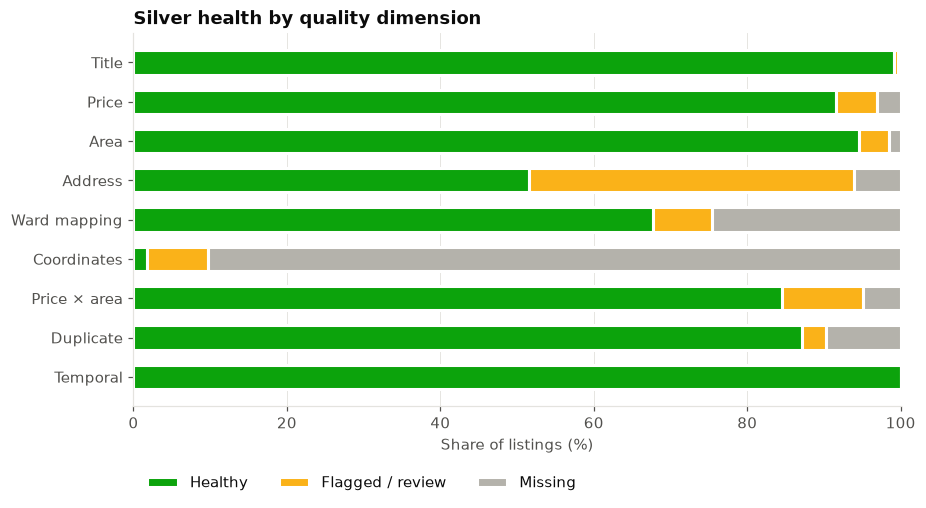

,Healthy,Flagged / review,Missing
Dimension,,,
Title,131318,653,523
Price,128118,7478,4376
Area,130375,5305,2119
Address,68196,55932,8117
Ward mapping,89697,10194,32603
Coordinates,2277,10572,119645
Price × area,111965,14054,6475
Duplicate,115464,4196,12834
Temporal,132485,9,0


In [32]:
canonical_silver_df = conn.execute("SELECT * FROM read_parquet(?)", [str(SILVER_PATH)]).df()
assert len(canonical_silver_df) == len(silver_df)
assert canonical_silver_df.rental_post_id.notna().all()
assert canonical_silver_df.rental_post_id.nunique() == len(canonical_silver_df)
assert list(canonical_silver_df.columns) == list(silver_df.columns)
assert METADATA_PATH.exists()

health = pd.DataFrame(
    [
        [
            "Title",
            silver_df.title_quality_status.eq("USABLE").sum(),
            silver_df.title_quality_status.eq("TOO_SHORT").sum(),
            silver_df.title_quality_status.eq("MISSING").sum(),
        ],
        [
            "Price",
            silver_df.price_amount_clean.notna().sum(),
            silver_df.price_outlier_flag.sum(),
            silver_df.price_amount_clean.isna().sum(),
        ],
        [
            "Area",
            silver_df.area_value_clean.notna().sum(),
            silver_df.area_outlier_flag.sum(),
            silver_df.area_value_clean.isna().sum(),
        ],
        [
            "Address",
            silver_df.parse_status.eq("PARSED").sum(),
            silver_df.parse_status.isin(["PARTIALLY_PARSED", "UNRECOGNIZED_FORMAT"]).sum(),
            silver_df.parse_status.eq("NO_ADDRESS_EVIDENCE").sum(),
        ],
        [
            "Ward mapping",
            silver_df.ward_current.notna().sum(),
            silver_df.ward_mapping_status.isin(["UNMAPPED", "AMBIGUOUS"]).sum(),
            silver_df.ward_mapping_status.eq("MISSING").sum(),
        ],
        [
            "Coordinates",
            silver_df.has_trusted_coordinate.sum(),
            silver_df.coordinate_trust_reason.ne("MISSING_COORDINATE_PAIR").sum()
            - silver_df.has_trusted_coordinate.sum(),
            silver_df.coordinate_trust_reason.eq("MISSING_COORDINATE_PAIR").sum(),
        ],
        [
            "Price × area",
            silver_df.price_area_quality_status.eq("CHECKED_NO_FLAG").sum(),
            silver_df.price_area_quality_status.str.endswith("REVIEW").sum(),
            silver_df.price_area_quality_status.eq("INSUFFICIENT_DATA").sum(),
        ],
        [
            "Duplicate",
            silver_df.duplicate_candidate_status.eq("UNIQUE_FINGERPRINT").sum(),
            silver_df.duplicate_candidate_status.eq("POSSIBLE_DUPLICATE").sum(),
            silver_df.duplicate_candidate_status.eq("INSUFFICIENT_DATA").sum(),
        ],
        [
            "Temporal",
            silver_df.temporal_quality_status.eq("VALID").sum(),
            silver_df.temporal_quality_status.eq("REQUIRES_REVIEW").sum(),
            silver_df.temporal_quality_status.eq("INSUFFICIENT_DATA").sum(),
        ],
    ],
    columns=["Dimension", "Healthy", "Flagged / review", "Missing"],
).set_index("Dimension")

fig, ax = plt.subplots(figsize=(9, 4.4))
left = np.zeros(len(health))
for column, color in [
    ("Healthy", STATUS["good"]),
    ("Flagged / review", STATUS["warning"]),
    ("Missing", "#b4b2ab"),
]:
    share = health[column] / health.sum(axis=1) * 100
    ax.barh(
        health.index,
        share,
        left=left,
        color=color,
        height=0.62,
        edgecolor="white",
        linewidth=2,
        label=column,
    )
    left += share.to_numpy()
ax.invert_yaxis()
ax.set(xlim=(0, 100), xlabel="Share of listings (%)", title="Silver health by quality dimension")
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, -0.15))
plt.show()
display(health)
pd.testing.assert_frame_equal(silver_df[BRONZE_COLUMNS], RAW_FINGERPRINT)
conn.close()

## Summary

In [33]:
review_rows = int(silver_df.row_quality_status.eq("REQUIRES_REVIEW").sum())
display(
    Markdown(
        f"""
**Key findings**

- **{len(silver_df):,}** listings from **{silver_df.source_code.nunique()}** sources were cleaned; no row was dropped and raw fields are unchanged.
- Quality gate: **{passed}/{len(gate)}** invariants pass, and the published Silver file matches this rebuild row for row.
- Clean price is available for **{silver_df.price_amount_clean.notna().mean():.1%}** of listings and clean area for **{silver_df.area_value_clean.notna().mean():.1%}**.
- Price parsers disagree on **{int(comparison.eq("DISAGREEMENT").sum()):,}** listings; the existing accepted value is kept and the disagreement stays visible.
- Only **{silver_df.has_trusted_coordinate.mean():.1%}** of listings have a trusted coordinate; most have none.
- **{int(silver_df.duplicate_candidate_status.eq("POSSIBLE_DUPLICATE").sum()):,}** listings are possible reposts (candidates, not confirmations).
- **{review_rows:,}** rows ({review_rows / len(silver_df):.1%}) still require review, mainly ambiguous wards and unusable titles.

**Next step:** Notebook 03 reads this Silver file and defines model eligibility and the feature contract.
"""
    )
)


**Key findings**

- **132,494** listings from **9** sources were cleaned; no row was dropped and raw fields are unchanged.
- Quality gate: **24/24** invariants pass, and the published Silver file matches this rebuild row for row.
- Clean price is available for **96.7%** of listings and clean area for **98.4%**.
- Price parsers disagree on **9,511** listings; the existing accepted value is kept and the disagreement stays visible.
- Only **1.7%** of listings have a trusted coordinate; most have none.
- **4,196** listings are possible reposts (candidates, not confirmations).
- **5,995** rows (4.5%) still require review, mainly ambiguous wards and unusable titles.

**Next step:** Notebook 03 reads this Silver file and defines model eligibility and the feature contract.
